# Loading functions and setting up data

In [1]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import scipy.stats as sp
import scipy.signal as sig
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy.linalg as LA
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from tqdm.auto import tqdm
import flox.xarray
from flox.xarray import xarray_reduce
from sklearn.linear_model import LinearRegression
plt.rcParams['font.family'] = 'serif' 
from matplotlib.legend_handler import HandlerTuple
import bokeh.palettes
from matplotlib import cm

## Functions

In [2]:
def lanczos_weights(window, freq_cutoff):
    """
    This function returns the lanczos weights necessary for filtering
    window is the length of the filter window you want to use
    freq_cutoff is the frequency you want to cut off at
    
    Code based on Libby Barnes github notebook:
    https://github.com/eabarnes1010/course_objective_analysis/blob/main/code/butterworth_lanczos_example.ipynb
    """
    
    order = ((window - 1) // 2 ) + 1
    nwts = 2 * order + 1
    w = np.zeros([nwts])
    n = nwts // 2
    w[n] = 2*freq_cutoff
    k = np.arange(1.,n)
    sigma = np.sin(np.pi * k/n) * n/(np.pi*k)
    firstfactor = np.sin(2.*np.pi*freq_cutoff*k)/(np.pi*k)
    
    w[n-1:0:-1] = firstfactor*sigma
    w[n+1:-1] = firstfactor*sigma
    
    return w[1:-1]

def filt_detrend(series, window, freq_cutoff):
    """
    This function takes a time series and detrends it by filtering out the
    low-frequencies using a lanczos filter (defined with the lanczos_weights
    function)
    """
    wgts = lanczos_weights(window,freq_cutoff)
    test_lp = sig.filtfilt(wgts,np.sum(wgts),series,padlen=0)
    test_hp = series-test_lp
    return test_hp

def month2year(var,experiment):
    '''
    This takes an xarray variable (var) and takes it from
    monthly to yearly data of length equal to the shortest
    data set for the given experiment
    '''

    if experiment == 'abrupt-4xCO2':
        var_mean = var.isel(time=slice(0,1800)).groupby('time.year').mean(skipna=True)
    elif experiment == 'piControl':
        var_mean = var.isel(time=slice(0,1200)).groupby('time.year').mean(skipna=True)
    elif experiment == '1pctCO2':
        var_mean = var.isel(time=slice(0,1800)).groupby('time.year').mean(skipna=True)
    else:
        var_mean = var.isel(time=slice(0,1980)).groupby('time.year').mean(skipna=True)
    return var_mean

def slide_anom(ts_abrupt,ts_pi,window_len):
    """
    Calculates anomalous values for your variable of interest against
    a running mean of piControl anomalies, this removes any potential model drift
    that may have existed in either simulations (assumes forced scenario drift is
    similar to piControl drift)

    for more details see first paragraph of Data section in Caldwell et al. (2016)
    [https://doi.org/10.1175/JCLI-D-15-0352.1]
    """
    conv = np.ones(window_len)*(1/window_len)
    ts_pi_conv = np.convolve(ts_pi,conv,'valid')
    index_len = np.floor(ts_abrupt.size/window_len)+2
    ts_anom = np.zeros(ts_abrupt.size)
    for i in np.arange(0,index_len,1):
        if i < np.max(np.arange(0,index_len,1)):
            ts_anom[int(i*window_len):int((i+1)*window_len)] = ts_abrupt[int(i*window_len):int((i+1)*window_len)] - ts_pi_conv[int(i)]
        elif i == np.max(np.arange(0,index_len,1)):
            ts_anom[int(i*window_len):int(-1)] = ts_abrupt[int(i*window_len):int(-1)] - ts_pi_conv[int(i)]

    return ts_anom
    
def drdt(temp_ts, rad_ts,n):
    '''
    Given a radiation ts and a temperature ts, this function
    will calculate dR/dT with n year windows
    '''
    drdt_ts = np.zeros(temp_ts.size-n)
    for i in np.arange(0,temp_ts.size-n,1):
        z = np.polyfit(temp_ts[i:i+n],rad_ts[i:i+n],1)
        p = np.poly1d(z)
        drdt_ts[i] = p[1]

    return drdt_ts

def potentialT(temp,ref_p,act_p):
    """
    Returns potential temperature given a temperature field and two pressure values
    ref_p is almost always 1000 [hPa]
    """
    Rd = 287 #[J/Kkg]
    cp = 1004 # [J/Kkg]
    theta = temp*((ref_p/act_p)**(Rd/cp))

    return theta

def equivtheta(temp_data, specifhumid_data,ref_p,act_p):
    """
    Mixing ratio (r) can be derived from specific humidity (hus, h): r = h/(1-h)
    Equivalent potential temperature is derived from temperature and mixing ratios
    
    Theta_e = (T + (Lv/cp)*r)*(p0/p)**(Rd/cp)
    
    Where Lv (2.256e6 [J/kg]) is the latent heat of condensation,
    cp (1004 [J/Kkg]) is the specific heat of air, r is the mixing ratio,
    p0 is the surface pressure (ref_p), p is the pressure at the height of interest (act_p),
    and Rd (287 [J/Kkg]) is the gas constant for dry air
    """

    Lv = 2.256e6 #[J/kg]
    cp = 1004 #[J/Kkg]
    Rd = 287 #[J/Kkg]
    r = (specifhumid_data)/(1-specifhumid_data)
    Theta_e = (temp_data + (Lv/cp)*r)*((ref_p/act_p)**(Rd/cp))

    return Theta_e

def equivtheta_ice(temp_ds, liquidr_ds, icer_ds, ref_p, act_p):
    """
    Using Tripoli and Cotton (1981)'s ice-liquid water potential temperature equation,
    where the water vapor has no impact on the specific heat capacity and the total pressure
    is approximately equal to the dry partial pressure, as well as the dependence of latent heat
    during phase changes on the temeprature is neglected.

    """

    Llv = 2.256e6 #[J/kg]
    Liv = 3008500 #[J/kg]
    cpd = 1004 #[J/Kkg]
    rl = (liquidr_ds)/(1-liquidr_ds)
    ri = icer_ds/(1-icer_ds)
    theta = potentialT(temp_ds,ref_p,act_p)
    equivtheta_ice = theta*np.exp(((Llv*rl)-(Liv*ri))/(cpd*ta_ds))
    
    return equivtheta_ice

def stratconv(ds,experiment):
    """
    Given your 3d cloud dataset (var 'cl'), define stratiform/convective
    clouds for your experiment, needs the month2year function loaded
    """
    if np.max(np.abs(ds['lev'])) <=1: #hybrid sigma
        ds = ds['cl'].isel(lev=slice(1,-1))
        ds = ds.sel(lev=slice(1,.650)).max(dim='lev')
        max_ds = month2year(ds,experiment)
    elif np.max(np.abs(ds['lev'])) > 1 and np.max(np.abs(ds['lev'])) < 1000: #actual pressure
        ds = ds['cl'].isel(lev=slice(1,-1))
        ds = ds.sel(lev=slice(-650,-1000)).max(dim='lev')
        max_ds = month2year(ds,experiment)
    elif np.max(np.abs(ds['lev'])) > 2000: #hybrid height
        ds = ds['cl'].isel(lev=slice(1,-1))
        ds = ds.sel(lev=slice(0,5000)).max(dim='lev')
        max_ds = month2year(ds,experiment)

    return max_ds

def shifted_colormap(cmap, new_range, n=256):
    if isinstance(cmap, str):
        cmap = mpl.colormaps[cmap]
    colors_list = cmap(np.linspace(new_range[0], new_range[1], n))
    return mpl.colors.LinearSegmentedColormap.from_list("new", colors_list)

## Dictionaries

In [3]:
#Determining which models have output for all relevant variables
#Importing all of the files
prefix = '/rugenstein-analysis/kpm17/'
vars = ['ta','tas','rsut','rsdt','rsutcs','rlut','rlutcs','clt','cl','hus','huss']

var_files = {}

for var in vars:
    files = []
    var_files[f'{var}_files'] = glob.glob(prefix+f'{var}_files/regrid_files/*')
    print(var_files[f'{var}_files'][1])
    print(len(var_files[f'{var}_files']))

var_models = {}

#Extracting the unique models for each variable
for var in vars:
    temp = []
    for i in np.arange(0,len(var_files[f'{var}_files'])):
        temp.append(var_files[f'{var}_files'][i].split('/')[-1].split('_')[2])
    var_models[f'{var}_models'] = temp
    print(f'Unique models in {var} files')
    print(np.unique(var_models[f'{var}_models']))
    print(len(np.unique(var_models[f'{var}_models'])))
    if var == 'cls':
        models = np.unique(var_models[f'{var}_models'])

models_by_var = {}

for var in vars:
    temp = []
    for i in np.arange(0,len(var_files[f'{var}_files'])):
        temp.append(var_files[f'{var}_files'][i].split('/')[-1].split('_')[2])
    models_by_var[var] = temp

modellist = sorted(list(set.intersection(*[set(l) for l in models_by_var.values()])))
print(modellist)
print(len(modellist))

modellist.remove('GISS-E2-1-G')
modellist.remove('GISS-E2-1-H')
modellist2 = modellist

/rugenstein-analysis/kpm17/ta_files/regrid_files/ta_Amon_IPSL-CM5A2-INCA_abrupt-4xCO2_r1i1p1f1_185001-199912_regrid.nc
204
/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_E3SM-2-0-NARRM_abrupt-4xCO2_r1i1p1f1_000101-015012_regrid.nc
204
/rugenstein-analysis/kpm17/rsut_files/regrid_files/rsut_Amon_CESM2-WACCM_abrupt-4xCO2_r1i1p1f1_000101-015012_regrid.nc
208
/rugenstein-analysis/kpm17/rsdt_files/regrid_files/rsdt_Amon_IPSL-CM5A2-INCA_piControl_r1i1p1f1_185001-209912_regrid.nc
203
/rugenstein-analysis/kpm17/rsutcs_files/regrid_files/rsutcs_Amon_MIROC6_1pctCO2_r1i1p1f1_320001-334912_regrid.nc
204
/rugenstein-analysis/kpm17/rlut_files/regrid_files/rlut_Amon_NorESM2-MM_piControl_r1i1p1f1_120001-169912_regrid.nc
204
/rugenstein-analysis/kpm17/rlutcs_files/regrid_files/rlutcs_Amon_NorESM2-MM_piControl_r1i1p1f1_120001-169912_regrid.nc
208
/rugenstein-analysis/kpm17/clt_files/regrid_files/clt_Amon_FIO-ESM-2-0_1pctCO2_r1i1p1f1_000101-015012_regrid.nc
200
/rugenstein-analysis/kpm17/cl_f

In [4]:
namelist_dict = {}
for var in vars:
    for i in np.arange(0,len(var_files[f'{var}_files']),1):
        experiment = var_files[f'{var}_files'][i].split('/')[-1].split('_')[3]
        model = var_files[f'{var}_files'][i].split('/')[-1].split('_')[2]
        if model in modellist:
            namelist_dict[(experiment,model)] = {'maps': {'clt':[],'rsut':[],'swcre':[],'albfor': [],'cldalb': []},
                                                'lats': {'clt':[],'rsut':[],'swcre':[], 'albfor': [],'cldalb': []},
                                                }
        else:
            pass

temp_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist:
    for experiment in exp_wanted:
        temp_dict[(experiment,model)] = {'maps': {'tas':[]},
                                        'lats': {'tas':[]},
                                         'TempProf': {},
                                        }

cloud_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist:
    for experiment in exp_wanted:
        cloud_dict[(experiment,model)] = {'maps': {'conv_early':[],'strat_early':[],'conv_late':[],'strat_late':[]},
                                        'lats': {'conv_early':[],'strat_early':[],'conv_late':[],'strat_late':[]},
                                        'ts': {'conv_so':[],'strat_so':[],'conv_nht':[],'strat_nht':[],'c/s':[],'c/s_anom': []}
                                        }

ecs_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist:
    for experiment in exp_wanted:
            ecs_dict[(experiment,model)] = {'pieces': {'ECS': [],'lambda': [],'Forcing': []}
                                                }

humidity_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist2:
    for experiment in exp_wanted:
        humidity_dict[(experiment,model)] = {'LTS': {'maps': [],'lats':[],'so_ts': [],'nht_ts':[]},
                                             'EIS': {'maps': [],'lats':[],'so_ts': [],'nht_ts':[]},
                                             'ECTEI': {'maps': [],'lats':[],'so_ts': [],'nht_ts':[]},
                                             'HumProf': {},
                                        }

hist_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist:
    for experiment in exp_wanted:
        hist_dict[(experiment,model)] = {'maps': {'tas':[]},
                                        'lats': {'tas':[]},
                                         'TempProf': {},
                                        }

hov_dict = {}
exp_wanted = ['1pctCO2','historical','abrupt-4xCO2','piControl']
for model in modellist:
    for experiment in exp_wanted:
        hov_dict[(experiment,model)] = {'temp_change': [], 'freetrop_sfc': [], 'cloudfrac_change': [], 'swcre_locallocal': [],
                                         'net_locallocal': [], 'net_localglobal': []}

In [5]:
#Defining time cut offs for the early vs late analysis
early_cut = 20
late_cut = 21

# Temperature Data

## Surface

In [6]:
#Adding data to the dictionary that gives information on the surface temperature change
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
for model in tqdm(modellist):
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    tas_ds = xr.open_dataset(tas_file).load()
    tas_ds = month2year(tas_ds,'abrupt-4xCO2')['tas']

    taspi_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_piControl*')[0]
    taspi_ds = xr.open_dataset(taspi_file).load()
    taspi_ds = month2year(taspi_ds,'piControl')['tas']
    
    taspi_map = taspi_ds.mean(dim='year',skipna=True)
    taspi_lats = taspi_ds.mean(dim='lon',skipna=True).mean(dim='year',skipna=True)
    temp_dict[('piControl',model)]['maps']['tas'] = taspi_map
    temp_dict[('piControl',model)]['lats']['tas'] = taspi_lats

    #Anomalizing relative to piControl climatology
    tas_earlyanom = tas_ds.isel(year=slice(0,early_cut)) - taspi_map
    tas_lateanom = tas_ds.isel(year=slice(late_cut,-1)) - taspi_map

    tas_ds = tas_ds - taspi_map
    socn_ts = (((tas_ds*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/((gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_ts = (((tas_ds*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/((gridarea).sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'socn_ts': socn_ts})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'nht_ts': nht_ts})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'diff_ts': nht_ts - socn_ts})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'diff_ts_late': (nht_ts - socn_ts).isel(year=slice(-11,-1)).mean(dim='year')})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'catch-up': (nht_ts - socn_ts).isel(year=slice(-11,-1)).mean(dim='year') - (nht_ts - socn_ts).isel(year=slice(0,10)).mean(dim='year')})
    
    #Creating the global mean surface temperature change timeseries
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]

    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'socn_tsnorm': socn_ts/tas_ts})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'nht_tsnorm': nht_ts/tas_ts})
    
    #Creating early period change and late period change
    gmst_early = tas_anom.isel(year=slice(19,21)).mean(dim='year',skipna=True)
    gmst_late = tas_anom.isel(year=slice(-6,-1)).mean(dim='year',skipna=True)

    #Normalizing by GMST change
    tas_earlynorm = tas_earlyanom/gmst_early
    tas_latenorm = tas_lateanom/gmst_late

    #Storing in dictionary
    temp_dict[('abrupt-4xCO2',model)]['maps'].update({'tas_earlynorm': tas_earlynorm.mean(dim='year',skipna=True)})
    temp_dict[('abrupt-4xCO2',model)]['maps'].update({'tas_latenorm': tas_latenorm.mean(dim='year',skipna=True)})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'tas_earlynorm': tas_earlynorm.mean(dim='lon',skipna=True).mean(dim='year',skipna=True)})
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'tas_latenorm': tas_latenorm.mean(dim='lon',skipna=True).mean(dim='year',skipna=True)})

    #hovmoller plots
    tas_hovmoller = tas_ds.mean(dim='lon',skipna=True)
    tas_hovmoller = tas_hovmoller - tas_hovmoller[0]
    temp_dict[('abrupt-4xCO2',model)]['lats'].update({'tas_hovmoller': tas_hovmoller})
    

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

## Atmosphere

In [7]:
#Lapse rates
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
nhtarea = gridarea.sel(lat=slice(-40,90))
for model in tqdm(modellist):
    experiment = 'abrupt-4xCO2'
    #Loading the data
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*{experiment}*')
    tas_ds = xr.open_dataset(tas_file[0])
    tas_ds = month2year(tas_ds,experiment)['tas']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*{experiment}*')
    ta_ds = xr.open_dataset(file_it[0]).load()
    ta_ds = month2year(ta_ds,experiment)['ta']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*piControl*')
    ta_dspi = xr.open_dataset(file_it[0]).load()
    ta_dspi = month2year(ta_dspi,experiment)['ta']
    
    #Defining global mean surface temperature change
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]
    socntas_ts = ((tas_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socntas_anom = socntas_ts - socntas_ts[0]
    
    #Creating early period change and late period change
    tas_early = tas_anom.isel(year=10)
    tas_late = tas_anom.isel(year=-1)
    socntas_early = socntas_anom.isel(year=slice(0,early_cut)).mean(dim='year')
    socntas_late = socntas_anom.isel(year=slice(late_cut,-1)).mean(dim='year')
    
    #Make the ta date only lat and plev
    ta_prof = ta_ds.mean(dim='lon',skipna=True)
    ta_anom = ta_prof.isel(year=0)
    #Choose early and late windows
    ta_early = ta_prof.isel(year=slice(0,early_cut)).mean(dim='year') - ta_anom
    ta_late = ta_prof.isel(year=slice(late_cut,-1)).mean(dim='year') - ta_anom
    temp_dict[(experiment,model)]['TempProf'].update({'ta_early': ta_early})
    temp_dict[(experiment,model)]['TempProf'].update({'ta_late': ta_late})

    #Dividing the temperature change by the global mean surface temperature change
    norm_early = ta_early/tas_early
    norm_late = ta_late/tas_late
    temp_dict[(experiment,model)]['TempProf'].update({'norm_early': norm_early})
    temp_dict[(experiment,model)]['TempProf'].update({'norm_late': norm_late})

    norm_earlysocn = ta_early/socntas_early
    norm_latesocn = ta_late/socntas_late
    temp_dict[(experiment,model)]['TempProf'].update({'norm_earlysocn': norm_earlysocn})
    temp_dict[(experiment,model)]['TempProf'].update({'norm_latesocn': norm_latesocn})


    ta_ds = ta_ds.isel(plev=slice(1,-1))
    ta_dspi = ta_dspi.isel(plev=slice(1,-1))
    #Setting up data for the S. Ocn and NH+T temperature profiles
    socntempprof = ta_ds.sel(lat=slice(-60,-40))
    nhttempprof = ta_ds.sel(lat=slice(-40,90))
    socnarea = gridarea.sel(lat=slice(-60,-40))
    nhtarea = gridarea.sel(lat=slice(-40,90))
    
    socntempprofpi = ta_dspi.sel(lat=slice(-60,-40))
    nhttempprofpi = ta_dspi.sel(lat=slice(-40,90))
    
    #Area averaging 
    socntempprof = ((socntempprof*socnarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhttempprof = ((nhttempprof*nhtarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(nhtarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socntempprofpi = ((socntempprofpi*socnarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhttempprofpi = ((nhttempprofpi*nhtarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(nhtarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    temp_dict[(experiment,model)]['TempProf'].update({'socn_piprof': socntempprofpi})
    temp_dict[(experiment,model)]['TempProf'].update({'nht_piprof': nhttempprofpi})
    
    socnanom = socntempprofpi.mean(dim='year',skipna=True)
    nhtanom = nhttempprofpi.mean(dim='year',skipna=True)
    
    temp_dict[(experiment,model)]['TempProf'].update({'socn_theta': socntempprof})
    #Creating early and late profiles
    socntp_early = socntempprof.isel(year=slice(0,early_cut)).mean(dim='year',skipna=True) - socntempprof.isel(year=0)
    socntp_late = socntempprof.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True) - socntempprof.isel(year=0)
    
    nhttp_early = nhttempprof.isel(year=slice(0,early_cut)).mean(dim='year') - nhtanom
    nhttp_late = nhttempprof.isel(year=slice(late_cut,-1)).mean(dim='year') - nhtanom

    #Storing in dictionary
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_early': socntempprof.isel(year=slice(0,10)).mean(dim='year',skipna=True)})
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_late': socntempprof.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_early': nhttempprof.isel(year=slice(0,10)).mean(dim='year',skipna=True)})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_late': nhttempprof.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)})
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_earlyanom': socntp_early})
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_lateanom': socntp_late})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_earlyanom': nhttp_early})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_earlyanom': nhttp_early})

    #Calculating profile shape differences
    #Subtract out surface temperature
    socntp_earlynorm = socntp_early - socntp_early[0]
    socntp_latenorm = socntp_late - socntp_late[0]
    nhttp_earlynorm = nhttp_early - nhttp_early[0]
    nhttp_latenorm = nhttp_late - nhttp_late[0]
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_earlynorm': socntp_earlynorm})
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_latenorm': socntp_latenorm})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_earlynorm': nhttp_earlynorm})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_latenorm': nhttp_latenorm})
    socntp_diffprof = socntp_latenorm - socntp_earlynorm
    nhttp_diffprof = nhttp_latenorm - nhttp_earlynorm
    
    temp_dict[(experiment,model)]['TempProf'].update({'socntp_diffprof': socntp_diffprof})
    temp_dict[(experiment,model)]['TempProf'].update({'nhttp_diffprof': nhttp_diffprof})
    
    #Normalizing the above by surface temp change
    socnnorm_early = socntp_early/tas_early
    socnnorm_late = socntp_late/tas_late
    
    nhtnorm_early = nhttp_early/tas_early
    nhtnorm_late = nhttp_late/tas_late

    temp_dict[(experiment,model)]['TempProf'].update({'socnnorm_early': socnnorm_early})
    temp_dict[(experiment,model)]['TempProf'].update({'socnnorm_late': socnnorm_late})
    temp_dict[(experiment,model)]['TempProf'].update({'nhtnorm_early': nhtnorm_early})
    temp_dict[(experiment,model)]['TempProf'].update({'nhtnorm_late': nhtnorm_late})

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

In [8]:
#S. Ocn Free Troposphere and Tropical Surface temperatures
for model in tqdm(modellist):
    experiment = 'abrupt-4xCO2'
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    tas_ds = xr.open_dataset(file_it[0]).load()
    tas_ds = month2year(tas_ds,experiment)['tas']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    ta_ds = xr.open_dataset(file_it[0]).load()
    ta_ds = month2year(ta_ds,experiment)['ta']

    socn_freetrop = ta_ds.sel(plev=slice(70000,30000)).mean(dim='plev',skipna=True)
    socn_freetrop = ((socn_freetrop*socnarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    temp_dict[(experiment,model)]['TempProf'].update({'socn_freetrop': socn_freetrop})
    
    tropics = (((tas_ds*gridarea).sel(lat=slice(-20,20))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/((gridarea.sel(lat=slice(-20,20))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    temp_dict[(experiment,model)]['TempProf'].update({'tropics': tropics})
    
    socn_freetropdetrend = filt_detrend(socn_freetrop,21,.1)
    tropicsdetrend = filt_detrend(tropics,21,.1)
    temp_dict[(experiment,model)]['TempProf'].update({'socn_freetropdetrend': socn_freetropdetrend})
    temp_dict[(experiment,model)]['TempProf'].update({'tropicsdetrend': tropicsdetrend})

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

# Cloud Data

In [9]:
#Adding data to the dictionary that gives information on the stratiform cloud cover through time
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
exp_wanted = 'abrupt-4xCO2'
for model in tqdm(modellist):
    print(model+'_'+experiment)
    clt_file = glob.glob(f'/rugenstein-analysis/kpm17/clt_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    clt_ds = xr.open_dataset(clt_file).load()
    clt_ds = month2year(clt_ds,'abrupt-4xCO2')['clt']

    cl_file = glob.glob(f'/rugenstein-analysis/kpm17/cl_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    cl_ds = xr.open_dataset(cl_file)

    if np.abs(np.max(clt_ds)) <= 1:
        clt_ds = clt_ds*100
    else:
        pass
    
    #If-else statement to handle the various pressure variables
    strat_ds = stratconv(cl_ds,'abrupt-4xCO2')

    if np.abs(np.max(strat_ds)) <= 1:
        strat_ds = strat_ds*100
    else:
        pass
    conv_ds = clt_ds.drop_vars('year') - strat_ds.drop_vars('year')

    #Time series by region
    conv_so = ((conv_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    conv_nht = ((conv_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    strat_so = ((strat_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    strat_nht = ((strat_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))    
    net_so = ((clt_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    net_nht = ((clt_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    cloud_dict[('abrupt-4xCO2',model)]['ts']['conv_so'] = conv_so
    cloud_dict[('abrupt-4xCO2',model)]['ts']['conv_nht'] = conv_nht
    cloud_dict[('abrupt-4xCO2',model)]['ts']['strat_so'] = strat_so
    cloud_dict[('abrupt-4xCO2',model)]['ts']['strat_nht'] = strat_nht
    cloud_dict[('abrupt-4xCO2',model)]['ts']['net_so'] = net_so
    cloud_dict[('abrupt-4xCO2',model)]['ts']['net_nht'] = net_nht

    #Calculating ratios
    socncloud_ratio = conv_so/strat_so
    socnratio_anom = socncloud_ratio - socncloud_ratio[0]
    cloud_dict[('abrupt-4xCO2',model)]['ts']['socn_c/s'] = socncloud_ratio
    cloud_dict[('abrupt-4xCO2',model)]['ts']['socn_c/s_anom'] = socnratio_anom
    nhtcloud_ratio = conv_nht/strat_nht
    nhtratio_anom = nhtcloud_ratio - nhtcloud_ratio[0]
    cloud_dict[('abrupt-4xCO2',model)]['ts']['nht_c/s'] = nhtcloud_ratio
    cloud_dict[('abrupt-4xCO2',model)]['ts']['nht_c/s_anom'] = nhtratio_anom

    ratio_map = conv_ds/strat_ds
    ratioanom_map = ratio_map - ratio_map.isel(year=0)
    ratiosm00ness_map = ratioanom_map.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    cloud_dict[('abrupt-4xCO2',model)]['maps']['ratioanom_map'] = ratioanom_map
    cloud_dict[('abrupt-4xCO2',model)]['maps']['ratiosm00ness_map'] = ratiosm00ness_map

  0%|          | 0/26 [00:00<?, ?it/s]

ACCESS-CM2_abrupt-4xCO2


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

ACCESS-ESM1-5_abrupt-4xCO2


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 101-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0101-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

BCC-CSM2-MR_abrupt-4xCO2
CESM2_abrupt-4xCO2
CESM2-FV2_abrupt-4xCO2
CESM2-WACCM_abrupt-4xCO2
CIESM_abrupt-4xCO2
CMCC-CM2-SR5_abrupt-4xCO2
CMCC-ESM2_abrupt-4xCO2
CNRM-CM6-1_abrupt-4xCO2
CanESM5_abrupt-4xCO2
E3SM-1-0_abrupt-4xCO2
E3SM-2-0_abrupt-4xCO2
EC-Earth3-AerChem_abrupt-4xCO2
FGOALS-f3-L_abrupt-4xCO2
FGOALS-g3_abrupt-4xCO2
HadGEM3-GC31-LL_abrupt-4xCO2
HadGEM3-GC31-MM_abrupt-4xCO2
MIROC6_abrupt-4xCO2


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/

MPI-ESM-1-2-HAM_abrupt-4xCO2
MPI-ESM1-2-HR_abrupt-4xCO2
MPI-ESM1-2-LR_abrupt-4xCO2
MRI-ESM2-0_abrupt-4xCO2
SAM0-UNICON_abrupt-4xCO2
TaiESM1_abrupt-4xCO2
UKESM1-0-LL_abrupt-4xCO2


# ECS/Feedbacks Data

In [ ]:
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
for model in tqdm(modellist):
    print(model)
    experiment = 'abrupt-4xCO2'
    rsut_file = glob.glob(f'/rugenstein-analysis/kpm17/rsut_files/regrid_files/rsut_Amon_{model}_{experiment}*.nc')[0]
    rsutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rsutcs_files/regrid_files/rsutcs_Amon_{model}_{experiment}*.nc')[0]
    rsdt_file = glob.glob(f'/rugenstein-analysis/kpm17/rsdt_files/regrid_files/rsdt_Amon_{model}_{experiment}*.nc')[0]
    rlut_file = glob.glob(f'/rugenstein-analysis/kpm17/rlut_files/regrid_files/rlut_Amon_{model}_{experiment}*.nc')[0]
    rlutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rlutcs_files/regrid_files/rlutcs_Amon_{model}_{experiment}*.nc')[0]
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_{model}_{experiment}*.nc')[0]
    taspi_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_{model}_piControl*.nc')[0]

    rsut_ds = month2year(xr.open_dataset(rsut_file).load(),experiment)['rsut']
    rsutcs_ds =  month2year(xr.open_dataset(rsutcs_file).load(),experiment)['rsutcs']
    rsdt_ds = month2year(xr.open_dataset(rsdt_file).load(),experiment)['rsdt']
    rlut_ds = month2year(xr.open_dataset(rlut_file).load(),experiment)['rlut']
    rlutcs_ds = month2year(xr.open_dataset(rlutcs_file).load(),experiment)['rlutcs']
    tas_ds = month2year(xr.open_dataset(tas_file).load(),experiment)['tas']
    swcre_ds = (rsut_ds - rsutcs_ds)*(-1)
    lwcre_ds = (rlut_ds - rlutcs_ds)*(-1)
    cre_ds = swcre_ds + lwcre_ds
    #subtracting to make everything positive down
    net_ds = rsdt_ds - rsut_ds - rlut_ds

    rsut_mean = ((rsut_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    rsdt_mean = ((rsdt_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    rlut_mean = ((rlut_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    tas_mean = ((tas_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    swcre_mean = ((swcre_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    net_mean = ((net_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))

    #Calculating ECS (ultimately Zelinka et al. 2020 ECS is used, though no significant differences exist)
    taspi_ds = month2year(xr.open_dataset(taspi_file).load(),'piControl')['tas']
    taspi_mean = ((taspi_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    tas_mean_anom = slide_anom(tas_mean,taspi_mean,21)
    tas_anom_map = np.empty([tas_ds.shape[0],tas_ds.shape[1],tas_ds.shape[2]])
    for y in np.arange(0,tas_ds.shape[1],1):
        for x in np.arange(0,tas_ds.shape[2],1):
            tas_anom_map[:,y,x] = slide_anom(tas_ds[:,y,x],taspi_ds[:,y,x],21)

    xvar = tas_mean_anom
    yvar = net_mean
    z = np.polyfit(xvar,yvar,1)
    slope = z[0]
    yint = z[1]
    xint = (-yint)/(slope)

    ecs_dict[(experiment,model)]['pieces']['ECS'] = xint/2
    ecs_dict[(experiment,model)]['pieces']['lambda'] = slope
    ecs_dict[(experiment,model)]['pieces']['Forcing'] = yint/2

    #Setting up feedback analysis
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    gmst_change = tas_ts - tas_ts[0]

    nhttas_ts = ((tas_ds*gridarea).sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhtst_change = nhttas_ts - nhttas_ts[0]
    
    sotas_ts = ((tas_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    sost_change = sotas_ts - sotas_ts[0]

    diff_change = nhtst_change - sost_change
    
    socn_cre = ((cre_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_swcre = ((swcre_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_net = ((net_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_swcre = ((swcre_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_cre = ((cre_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_net = ((net_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    
    socn_creanom = socn_cre - socn_cre[0]
    socn_swcreanom = socn_swcre - socn_swcre[0]
    socn_netanom = socn_net - socn_net[0]
    globe_creanom = globe_cre - globe_cre[0]
    globe_swcreanom = globe_swcre - globe_swcre[0]
    globe_netanom = globe_net - globe_net[0]
    
    ecs_dict[(experiment,model)].update({'globe_net': globe_netanom})
    ecs_dict[(experiment,model)].update({'globe_swcre': globe_swcreanom})
    ecs_dict[(experiment,model)].update({'socn_swcreanom': socn_swcreanom})
    ecs_dict[(experiment,model)].update({'sost_change': sost_change})
    ecs_dict[(experiment,model)].update({'gmst_change': gmst_change})

    #Feedback calculations with a 30 year window
    dRswcldso_dTso = drdt(sost_change,socn_swcreanom,30)
    dRswcldso_dTglobe = drdt(gmst_change,socn_swcreanom,30)
    dRswcld_dTso = drdt(sost_change,globe_swcreanom,30)
    dRswcld_dTglobe = drdt(gmst_change,globe_swcreanom,30)
    dRnet_dTso = drdt(sost_change,globe_netanom,30)
    dRnetso_dTglobe = drdt(gmst_change,socn_netanom,30)
    dRnet_dTglobe = drdt(gmst_change,globe_netanom,30)

    #Storing in dictionary
    ecs_dict[(experiment,model)].update({'dRswcldso_dTso': dRswcldso_dTso})
    ecs_dict[(experiment,model)].update({'swcldso': socn_swcreanom})
    ecs_dict[(experiment,model)].update({'Tso': sost_change})
    ecs_dict[(experiment,model)].update({'dRswcldso_dTglobe': dRswcldso_dTglobe})
    ecs_dict[(experiment,model)].update({'dRswcld_dTso': dRswcld_dTso})
    ecs_dict[(experiment,model)].update({'dRswcld_dTglobe': dRswcld_dTglobe})
    ecs_dict[(experiment,model)].update({'dRnet_dTso': dRnet_dTso})
    ecs_dict[(experiment,model)].update({'dRnetso_dTglobe': dRnetso_dTglobe})
    ecs_dict[(experiment,model)].update({'dRnet_dTglobe': dRnet_dTglobe})


  0%|          | 0/26 [00:00<?, ?it/s]

ACCESS-CM2


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

ACCESS-ESM1-5


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 101-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0101-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

...

MPI-ESM1-2-LR


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/scratch/kpm17/miniconda3/envs/general/l

MRI-ESM2-0


/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/scratch/kpm17/miniconda3/envs/general/l

SAM0-UNICON
TaiESM1


In [ ]:
#ECS Dictionary
ratio_change = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is
    test3 = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    ratio_change[i] = (test3 - test3[0]).isel(year=slice(late_cut,-1)).mean(dim='year')

modelname = [k for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(cloudratio = ratio_change,
         names = modelnames
    )
)
smesque_sorted = df.sort_values('cloudratio')
smesque_sorted = smesque_sorted.reset_index(drop=True)
smesque_sorted

modelname = [k for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(ECS = [v['pieces']['ECS'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         mine = [v['pieces']['ECS'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = modelnames
    )
)
ecs_sorted = df.sort_values('ECS')
ecs_sorted = ecs_sorted.reset_index(drop=True)
ecs_sorted

comb_df = pd.merge(smesque_sorted,ecs_sorted,how='inner',on='names')
comb_df.sort_values('names')

#From Zelinka
comb_df.loc[comb_df['names'] == 'ACCESS-CM2','ECS'] = 4.66
comb_df.loc[comb_df['names'] == 'ACCESS-ESM1-5','ECS'] = 3.88
comb_df.loc[comb_df['names'] == 'BCC-CSM2-MR','ECS'] = 3.02
comb_df.loc[comb_df['names'] == 'BCC-ESM1','ECS'] = 3.25
comb_df.loc[comb_df['names'] == 'CAMS-CSM1-0','ECS'] = 2.29
comb_df.loc[comb_df['names'] == 'CESM2','ECS'] = 5.15
comb_df.loc[comb_df['names'] == 'CESM2-FV2','ECS'] = 5.16
comb_df.loc[comb_df['names'] == 'CESM2-WACCM','ECS'] = 4.68
comb_df.loc[comb_df['names'] == 'CIESM','ECS'] = 5.63
comb_df.loc[comb_df['names'] == 'CMCC-CM2-SR5','ECS'] = 3.55
comb_df.loc[comb_df['names'] == 'CMCC-ESM2','ECS'] = 3.58
comb_df.loc[comb_df['names'] == 'CNRM-CM6-1','ECS'] = 4.90
comb_df.loc[comb_df['names'] == 'CanESM5','ECS'] = 5.64
comb_df.loc[comb_df['names'] == 'E3SM-1-0','ECS'] = 5.31
comb_df.loc[comb_df['names'] == 'EC-Earth3-AerChem','ECS'] = 3.87
comb_df.loc[comb_df['names'] == 'FGOALS-f3-L','ECS'] = 2.98
comb_df.loc[comb_df['names'] == 'FGOALS-g3','ECS'] = 2.87
comb_df.loc[comb_df['names'] == 'HadGEM3-GC31-LL','ECS'] = 5.55
comb_df.loc[comb_df['names'] == 'HadGEM3-GC31-MM','ECS'] = 5.44
comb_df.loc[comb_df['names'] == 'MIROC6','ECS'] = 2.60
comb_df.loc[comb_df['names'] == 'MPI-ESM-1-2-HAM','ECS'] = 2.95
comb_df.loc[comb_df['names'] == 'MPI-ESM1-2-HR','ECS'] = 2.98
comb_df.loc[comb_df['names'] == 'MPI-ESM1-2-LR','ECS'] = 3.03
comb_df.loc[comb_df['names'] == 'MRI-ESM2-0','ECS'] = 3.13
comb_df.loc[comb_df['names'] == 'SAM0-UNICON','ECS'] = 3.72
comb_df.loc[comb_df['names'] == 'TaiESM1','ECS'] = 4.36
comb_df.loc[comb_df['names'] == 'UKESM1-0-LL','ECS'] = 5.36

In [ ]:
#Feedbacks Dictionary
ratio_change = np.empty([len(modellist)])
strat_change = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is
    test3 = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    ratio_change[i] = (test3 - test3[0]).isel(year=slice(late_cut,-1)).mean(dim='year')
    test2 = [v['ts']['strat_so'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    strat_change[i] = (test2 - test2[0]).isel(year=slice(late_cut,-1)).mean(dim='year')
    

modelname = [k for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(cloudratio = ratio_change,
         strat_change = strat_change,
         names = modelnames
    )
)
smesque_sorted = df.sort_values('cloudratio')
smesque_sorted = smesque_sorted.reset_index(drop=True)
smesque_sorted

#Calculating the change in all the feedbacks and radiation
swcre_change = np.empty([len(modellist)])
dRswcldso_dTso_change = np.empty([len(modellist)])
dRswcldso_dTglobe_change = np.empty([len(modellist)])
dRswcld_dTglobe_change = np.empty([len(modellist)])
dRnetso_dTglobe_change = np.empty([len(modellist)])
dRnet_dTglobe_change = np.empty([len(modellist)])
globeswfeedback = np.empty([len(modellist)])
globenotswfeedback = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    socn_swcreanom = [v['socn_swcreanom'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    dRswcldso_dTso = [v['dRswcldso_dTso'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    dRswcldso_dTglobe = [v['dRswcldso_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    dRswcld_dTglobe = [v['dRswcld_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    dRnet_dTglobe = [v['dRnet_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    dRnetso_dTglobe = [v['dRnetso_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    swcre_change[i] = np.nanmean((socn_swcreanom - socn_swcreanom[0])[late_cut:-1],0) - np.nanmean((socn_swcreanom - socn_swcreanom[0])[0:early_cut],0)
    dRswcldso_dTso_change[i] = np.nanmean((dRswcldso_dTso - dRswcldso_dTso[0])[late_cut:-1],0) - np.nanmean((dRswcldso_dTso - dRswcldso_dTso[0])[0:early_cut],0)
    dRswcldso_dTglobe_change[i] = np.nanmean((dRswcldso_dTglobe - dRswcldso_dTglobe[0])[late_cut:-1],0) - np.nanmean((dRswcldso_dTglobe - dRswcldso_dTglobe[0])[0:early_cut],0)
    dRswcld_dTglobe_change[i] = np.nanmean((dRswcld_dTglobe - dRswcld_dTglobe[0])[late_cut:-1],0) - np.nanmean((dRswcld_dTglobe - dRswcld_dTglobe[0])[0:early_cut],0)
    dRnetso_dTglobe_change[i] = np.nanmean((dRnetso_dTglobe - dRnetso_dTglobe[0])[late_cut:-1],0) - np.nanmean((dRnetso_dTglobe - dRnetso_dTglobe[0])[0:early_cut],0)
    dRnet_dTglobe_change[i] = np.nanmean((dRnet_dTglobe - dRnet_dTglobe[0])[late_cut:-1],0) - np.nanmean((dRnet_dTglobe - dRnet_dTglobe[0])[0:early_cut],0)
    globeswfeedback[i] = np.mean(dRswcld_dTglobe,0)
    globenotswfeedback[i] = np.mean(dRnet_dTglobe - dRswcld_dTglobe,0)

modelname = [k for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(feedbacks = [v['pieces']['lambda'] for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         swcre_change = swcre_change,
         globeswfeedback = globeswfeedback,
         globenotswfeedback = globenotswfeedback,
         dRswcldso_dTso_change = dRswcldso_dTso_change,
         dRswcldso_dTglobe_change = dRswcldso_dTglobe_change,
         dRswcld_dTglobe_change = dRswcld_dTglobe_change,
         dRnet_dTglobe_change = dRnet_dTglobe_change,
         dRnetso_dTglobe_change = dRnetso_dTglobe_change,
         names = modelnames
    )
)
feedbacks_sorted = df.sort_values('names')
feedbacks_sorted = feedbacks_sorted.reset_index(drop=True)

feedbacks_merge = pd.merge(smesque_sorted,feedbacks_sorted,how='inner',on='names')

# Humidity Data

In [13]:
vars = ['ta']
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
nhtarea = gridarea.sel(lat=slice(-40,90))
for model in tqdm(modellist2):
    #Loading the data
    experiment = 'abrupt-4xCO2'
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    hus_ds = xr.open_dataset(file_it[0]).load()
    hus_ds = month2year(hus_ds,experiment)['hus']

    file_it = glob.glob(f'/rugenstein-analysis/kpm17/huss_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    huss_ds = xr.open_dataset(file_it[0]).load()
    huss_ds = month2year(huss_ds,experiment)['huss']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_*piControl*')
    hus_dspi = xr.open_dataset(file_it[0]).load()
    hus_dspi = month2year(hus_dspi,'piControl')['hus']
    
    ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    ps_ds = xr.open_dataset(ps_file[0])
    ps_ds = month2year(ps_ds,experiment)['ps']
    
    ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_*piControl*')
    ps_dspi = xr.open_dataset(ps_file[0])
    ps_dspi = month2year(ps_dspi,'piControl')['ps']
    
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    tas_ds = xr.open_dataset(tas_file[0])
    tas_ds = month2year(tas_ds,experiment)['tas']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*abrupt-4xCO2*')
    ta_ds = xr.open_dataset(file_it[0]).load()
    ta_ds = month2year(ta_ds,experiment)['ta']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*piControl*')
    ta_dspi = xr.open_dataset(file_it[0]).load()
    ta_dspi = month2year(ta_dspi,'piControl')['ta']

    #Defining global mean surface temperature change
    epttas = equivtheta(tas_ds.drop('year'),huss_ds.drop('year'),ps_ds.drop('year'),ps_ds.drop('year'))
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socntas_ts = ((tas_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]
    socntas_anom = socntas_ts - socntas_ts[0]
    
    #Creating early period change and late period change
    tas_early = tas_anom.isel(year=slice(0,early_cut)).mean(dim='year',skipna=True)
    tas_late = tas_anom.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    socntas_early = socntas_anom.isel(year=slice(0,early_cut)).mean(dim='year',skipna=True)
    socntas_late = socntas_anom.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    
    #Make the ta date only lat and plev
    ept_ds = equivtheta(ta_ds.drop('year'),hus_ds.drop('year'),ps_ds.drop('year'),ta_ds['plev'])
    ta_prof = ept_ds.mean(dim='lon',skipna=True)
    ta_anom = ta_prof.isel(year=0)
    #Choose early and late windows
    ta_early = ta_prof.isel(year=slice(0,early_cut)).mean(dim='year') - ta_anom
    ta_late = ta_prof.isel(year=slice(late_cut,-1)).mean(dim='year') - ta_anom

    #Dividing the temperature change by the global mean surface temperature change
    norm_early = ta_early/tas_early
    norm_late = ta_late/tas_late
    socnnorm_early = ta_early/socntas_early
    socnnorm_late = ta_late/socntas_late
    humidity_dict[(experiment,model)]['HumProf'].update({'norm_early': norm_early})
    humidity_dict[(experiment,model)]['HumProf'].update({'norm_late': norm_late})
    humidity_dict[(experiment,model)]['HumProf'].update({'socnnorm_early': socnnorm_early})
    humidity_dict[(experiment,model)]['HumProf'].update({'socnnorm_late': socnnorm_late})
    
    #Make the hus date only lat and plev
    huss_ts = ((huss_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    huss_anom = huss_ts# - huss_ts[0]
    huss_early = huss_anom.isel(year=early_cut)
    huss_late = huss_anom.isel(year=-1)
    earlyprof = hus_ds.mean(dim='lon').isel(year=slice(0,early_cut)).mean(dim='year',skipna=True)
    lateprof = hus_ds.mean(dim='lon').isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    hus_prof = hus_ds.mean(dim='lon',skipna=True) - hus_dspi.mean(dim='lon',skipna=True).mean(dim='year',skipna=True)
    #Choose early and late windows
    humidity_dict[(experiment,model)]['HumProf'].update({'hus_early': earlyprof})
    humidity_dict[(experiment,model)]['HumProf'].update({'hus_late': lateprof})
    humidity_dict[(experiment,model)]['HumProf'].update({'hus_earlynorm': earlyprof/huss_early})
    humidity_dict[(experiment,model)]['HumProf'].update({'hus_latenorm': lateprof/huss_late})

    #Equiv. Potential Temperature Plots
    hus_ds = hus_ds.isel(plev=slice(1,-1))    
    hus_dspi = hus_dspi.isel(plev=slice(1,-1))
    ta_ds = ta_ds.isel(plev=slice(1,-1))
    ta_dspi = ta_dspi.isel(plev=slice(1,-1))
    mixing_r = (hus_ds)/(1 - hus_ds)
    mixing_rpi = (hus_dspi)/(1 - hus_dspi)
    theta_e = equivtheta(ta_ds, hus_ds, ps_ds, ta_ds['plev'])
    theta_epi = equivtheta(ta_dspi, hus_dspi, ps_dspi, ta_dspi['plev'])
    theta = potentialT(ta_ds,ps_ds,ta_ds['plev'])
    thetapi = potentialT(ta_dspi,ps_dspi,ta_ds['plev'])

    #Mixing ratio values
    socn_r = (((mixing_r*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_rpi = (((mixing_rpi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_rclim = socn_rpi.mean(dim='year',skipna=True)
    nht_r = (((mixing_r*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_rpi = (((mixing_rpi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_rclim = nht_rpi.mean(dim='year',skipna=True)

    humidity_dict[(experiment,model)]['HumProf'].update({'socn_r': socn_r})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_r': nht_r})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_rclim': socn_rclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_rclim': nht_rclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_ranom': socn_r - socn_rclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_ranom': nht_r - nht_rclim})

    #Equivalent potential temperature values
    socn_thetae = (((theta_e*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaepi = (((theta_epi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaeclim = socn_thetaepi.mean(dim='year',skipna=True)
    nht_thetae = (((theta_e*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaepi = (((theta_epi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaeclim = nht_thetaepi.mean(dim='year',skipna=True)
    
    thetae_early = socn_thetae.isel(year=slice(0,early_cut)).mean(dim='year',skipna=True)
    thetae_late = socn_thetae.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    thetae_earlyanom = thetae_early - socn_thetae.isel(year=0)
    thetae_lateanom = thetae_late - socn_thetae.isel(year=0)

    humidity_dict[(experiment,model)]['HumProf'].update({'socn_thetae': socn_thetae})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_thetae': nht_thetae})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_thetaepiprof': socn_thetaeclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_thetaepiprof': nht_thetaeclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_thetaeanom': socn_thetae - socn_thetae.isel(year=0)})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_thetaeanom': nht_thetae - nht_thetae.isel(year=0)})

    #Potential temperature values
    socn_theta = (((theta*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetapi = (((thetapi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaclim = socn_thetapi.mean(dim='year',skipna=True)
    nht_theta = (((theta*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetapi = (((thetapi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaclim = nht_thetapi.mean(dim='year',skipna=True)
    
    theta_early = socn_theta.isel(year=slice(0,early_cut)).mean(dim='year',skipna=True)
    theta_late = socn_theta.isel(year=slice(late_cut,-1)).mean(dim='year',skipna=True)
    theta_earlyanom = theta_early - socn_thetaclim
    theta_lateanom = theta_late - socn_thetaclim

    humidity_dict[(experiment,model)]['HumProf'].update({'socn_theta': socn_theta})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_theta': nht_theta})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_thetapiprof': socn_thetaclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_thetapiprof': nht_thetaclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'socn_thetaanom': socn_theta - socn_thetaclim})
    humidity_dict[(experiment,model)]['HumProf'].update({'nht_thetaanom': nht_theta - nht_thetaclim})

/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

In [14]:
#Calculating the atmospheric profile shift for equivalent potential temperature in the Southern Ocean
data = np.nanmean([v['HumProf']['socn_thetaeanom'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
dataearly = np.nanmean(data[0:early_cut,:],0)
datalate = np.nanmean(data[late_cut:-1,:],0)
earlyshift = dataearly - dataearly[0]
lateshift = datalate - datalate[0]
thetaediffprof = lateshift-earlyshift
data = np.array([v['HumProf']['socn_thetaeanom'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'])
dataearly = np.nanmean(data[:,0:early_cut,:],1)
datalate = np.nanmean(data[:,late_cut:-1,:],1)
earlyshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
lateshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
for i in np.arange(0,dataearly.shape[0],1):
    earlyshift[i,:] = dataearly[i,:] - dataearly[i,0]
    lateshift[i,:] = datalate[i,:] - datalate[i,0]
thetaediffprofens = lateshift-earlyshift
socnpt_diffprof = np.nanmean([v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
socnpt_diffprofens = [v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2']

In [15]:
#Storing all equivalent potential temperature information in a dictionary for future analysis
cloud_change = np.empty([len(modellist)])
strat_change = np.empty([len(modellist)])
ratio_change = np.empty([len(modellist)])
stability_change = np.empty([len(modellist2)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is
    test = [v['ts']['conv_so'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    test2 = [v['ts']['strat_so'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    test3 = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2'][i]
    cloud_change[i] = (test - test[0]).isel(year=slice(late_cut,-1)).mean(dim='year')
    strat_change[i] = (test2 - test2[0]).isel(year=slice(late_cut,-1)).mean(dim='year')
    ratio_change[i] = (test3 - test3[0]).isel(year=slice(late_cut,-1)).mean(dim='year')

for i in np.arange(0,len(modellist2),1):
    #Selecting the pressure level I want to take the stability change from
    stability_change[i] = thetaediffprofens[i][2]

modelname = [k for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(cloudconv = cloud_change,
         cloudstrat = strat_change,
         cloudratio = ratio_change,
         names = modelnames
    )
)
clouds_sorted = df.sort_values('names')

modelname = [k for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(cloudstab = stability_change,
         names = modelnames
    )
)
stability_sorted = df.sort_values('names')
pd_merge = pd.merge(clouds_sorted,stability_sorted,how='inner',on='names')

## CESM2 Ice Equivalent Potential Data

In [16]:
#Loading in atmospheric temperature and humidity information
model = 'CESM2'
experiment = 'abrupt-4xCO2'
file_it = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_*abrupt-4xCO2*')
hus_ds = xr.open_dataset(file_it[0]).load()
hus_ds = month2year(hus_ds,experiment)['hus']
hus_ds = hus_ds.isel(plev=slice(1,-1))

file_it = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_*piControl*')
hus_dspi = xr.open_dataset(file_it[0]).load()
hus_dspi = month2year(hus_dspi,'piControl')['hus']
hus_dspi = hus_dspi.isel(plev=slice(1,-1))

ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_*abrupt-4xCO2*')
ps_ds = xr.open_dataset(ps_file[0])
ps_ds = month2year(ps_ds,experiment)['ps']

ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_*piControl*')
ps_dspi = xr.open_dataset(ps_file[0])
ps_dspi = month2year(ps_dspi,'piControl')['ps']

tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*abrupt-4xCO2*')
tas_ds = xr.open_dataset(tas_file[0])
tas_ds = month2year(tas_ds,experiment)['tas']

file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*abrupt-4xCO2*')
ta_ds = xr.open_dataset(file_it[0]).load()
ta_ds = month2year(ta_ds,experiment)['ta']
ta_ds = ta_ds.isel(plev=slice(1,-1))

file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*piControl*')
ta_dspi = xr.open_dataset(file_it[0]).load()
ta_dspi = month2year(ta_dspi,'piControl')['ta']
ta_dspi = ta_dspi.isel(plev=slice(1,-1))

In [17]:
#Loading in atmospheric ice content
file_it = glob.glob(f'/rugenstein-analysis/kpm17/cli_files/regrid_files/*_{model}_*abrupt-4xCO2*')
cli_ds = xr.open_dataset(file_it[0]).load()
cli_ds = month2year(cli_ds,experiment)['cli']
cli_ds['lev'] = cli_ds['lev']*-1
cli_ds = cli_ds.reindex(lev=cli_ds.lev[::-1])

file_it = glob.glob(f'/rugenstein-analysis/kpm17/cli_files/regrid_files/*_{model}_*abrupt-4xCO2*')
cli_ds = xr.open_dataset(file_it[0]).load()
cli_ds = month2year(cli_ds,experiment)['cli']
cli_ds['lev'] = cli_ds['lev']*-100
cli_ds = cli_ds.reindex(lev=cli_ds.lev[::-1])
cli_ds = cli_ds.rename({'lev': 'plev'})
cli_ds = cli_ds.interp(plev = np.array(ta_ds['plev']),method='nearest')

file_it = glob.glob(f'/rugenstein-analysis/kpm17/cli_files/regrid_files/*_{model}_*piControl*')
cli_dspi = xr.open_dataset(file_it[0]).load()
cli_dspi = month2year(cli_dspi,'piControl')['cli']
cli_dspi['lev'] = cli_dspi['lev']*-100
cli_dspi = cli_dspi.reindex(lev=cli_dspi.lev[::-1])
cli_dspi = cli_dspi.rename({'lev': 'plev'})
cli_dspi = cli_dspi.interp(plev = np.array(ta_ds['plev']),method='nearest')

gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
nhtarea = gridarea.sel(lat=slice(-40,90))

In [18]:
#Calculating mixing ratios, ice-equivalent, equivalent and standard potential temperature atmospheric profiles
mixing_r = (hus_ds)/(1 - hus_ds)
mixing_rpi = (hus_dspi)/(1 - hus_dspi)
theta_e = equivtheta(ta_ds, hus_ds, ps_ds, ta_ds['plev'])
theta_epi = equivtheta(ta_dspi, hus_dspi, ps_dspi, ta_dspi['plev'])
theta = potentialT(ta_ds,ps_ds,ta_ds['plev'])
thetapi = potentialT(ta_dspi,ps_dspi,ta_ds['plev'])
theta_ei = equivtheta_ice(ta_ds, hus_ds, cli_ds, ps_ds, ta_ds['plev'])
theta_eipi = equivtheta_ice(ta_dspi, hus_dspi, cli_dspi, ps_dspi, ta_dspi['plev'])
mixing_ri = cli_ds/(1-cli_ds)
mixing_ripi = cli_dspi/(1-cli_dspi)

In [19]:
socn_theta = (((theta*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetapi = (((thetapi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetaclim = socn_thetapi.mean(dim='year',skipna=True)
theta_early = socn_theta.isel(year=slice(0,10)).mean(dim='year',skipna=True)
theta_late = socn_theta.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)
theta_earlyanom = theta_early - socn_thetaclim
theta_lateanom = theta_late - socn_thetaclim

socn_thetae = (((theta_e*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetaepi = (((theta_epi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetaeclim = socn_thetaepi.mean(dim='year',skipna=True)
thetae_early = socn_thetae.isel(year=slice(0,10)).mean(dim='year',skipna=True)
thetae_late = socn_thetae.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)
thetae_earlyanom = thetae_early - socn_thetaeclim
thetae_lateanom = thetae_late - socn_thetaeclim

socn_thetaei = (((theta_ei*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetaeipi = (((theta_eipi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
socn_thetaeiclim = socn_thetaeipi.mean(dim='year',skipna=True)
thetaei_early = socn_thetaei.isel(year=slice(0,10)).mean(dim='year',skipna=True)
thetaei_late = socn_thetaei.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)
thetaei_earlyanom = thetaei_early - socn_thetaeiclim
thetaei_lateanom = thetaei_late - socn_thetaeiclim

# Historical Data

In [6]:
histearly = 20
histlate = -11

### Surface T

In [8]:
vars = ['ta']
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
nhtarea = gridarea.sel(lat=slice(-40,90))
for model in tqdm(modellist):
    experiment = 'historical'
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*{experiment}*')
    tas_ds = xr.open_dataset(file_it[0]).load()
    tas_ds = month2year(tas_ds,experiment)['tas']
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*{experiment}*')
    ta_ds = xr.open_dataset(file_it[0]).load()
    ta_ds = month2year(ta_ds,experiment)['ta']
    
    #Defining global mean surface temperature change
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]
    
    socntas_ts = (((tas_ds*socnarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhttas_ts = (((tas_ds*nhtarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(nhtarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_early = tas_anom.isel(year=10)
    tas_late = tas_anom.isel(year=-1)
    
    nhtclim = nhttas_ts.sel(year=slice(1850,1950)).mean(dim='year',skipna=True)
    nhtanom = nhttas_ts.sel(year=slice(1950,2015)) - nhtclim
    socnclim = socntas_ts.sel(year=slice(1850,1950)).mean(dim='year',skipna=True)
    socnanom = socntas_ts.sel(year=slice(1950,2015)) - socnclim

    hist_dict[(experiment,model)]['TempProf'].update({'socn_ts': socnanom})
    hist_dict[(experiment,model)]['TempProf'].update({'nht_ts': nhtanom})
    
    #Make the ta date only lat and plev
    ta_prof = ta_ds.mean(dim='lon',skipna=True)
    ta_anom = ta_prof.sel(year=slice(1850,1950)).mean(dim='year',skipna=True)
    #Choose early and late windows
    ta_early = ta_prof.sel(year=slice(1950,2014)).isel(year=slice(0,10)).mean(dim='year') - ta_anom
    ta_late = ta_prof.sel(year=slice(1950,2014)).isel(year=slice(-11,-1)).mean(dim='year') - ta_anom
    
    tasclim = tas_ts.sel(year=slice(1850,1950)).mean(dim='year',skipna=True)
    tas_early = tas_ts.sel(year=slice(1950,2014)).isel(year=slice(0,10)).mean(dim='year') - tasclim
    tas_late = tas_ts.sel(year=slice(1950,2014)).isel(year=slice(-11,-1)).mean(dim='year') - tasclim
    #Dividing the temperature change by the global mean surface temperature change
    norm_clim = ta_anom/tasclim
    norm_late = ta_late/tas_late
    hist_dict[(experiment,model)]['TempProf'].update({'norm_clim': norm_clim})
    hist_dict[(experiment,model)]['TempProf'].update({'norm_late': norm_late})

    ta_dsfull = ta_ds
    ta_ds = ta_dsfull.isel(plev=slice(1,-1)).sel(year=slice(1950,2014))
    ta_dspi = ta_dsfull.isel(plev=slice(1,-1)).sel(year=slice(1850,1950))
    #Setting up data for the S. Ocn and NH+T temperature profiles
    socntempprof = ta_ds.sel(lat=slice(-60,-40))
    nhttempprof = ta_ds.sel(lat=slice(-40,90))
    socnarea = gridarea.sel(lat=slice(-60,-40))
    nhtarea = gridarea.sel(lat=slice(-40,90))
    
    socntempprofpi = ta_dspi.sel(lat=slice(-60,-40))
    nhttempprofpi = ta_dspi.sel(lat=slice(-40,90))
    #Area averaging 
    socntempprof = ((socntempprof*socnarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhttempprof = ((nhttempprof*nhtarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(nhtarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socntempprofpi = ((socntempprofpi*socnarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(socnarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhttempprofpi = ((nhttempprofpi*nhtarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(nhtarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    hist_dict[(experiment,model)]['TempProf'].update({'socn_piprof': socntempprofpi})
    hist_dict[(experiment,model)]['TempProf'].update({'nht_piprof': nhttempprofpi})
    
    socnanom = socntempprofpi.mean(dim='year',skipna=True)
    nhtanom = nhttempprofpi.mean(dim='year',skipna=True)
    
    #Creating early and late profiles
    socntp_early = socntempprof.isel(year=slice(0,histearly)).mean(dim='year',skipna=True) - socnanom
    socntp_late = socntempprof.isel(year=slice(histlate,-1)).mean(dim='year',skipna=True) - socnanom
    
    nhttp_early = nhttempprof.isel(year=slice(0,histearly)).mean(dim='year') - nhtanom
    nhttp_late = nhttempprof.isel(year=slice(-histlate,-1)).mean(dim='year') - nhtanom

    hist_dict[(experiment,model)]['TempProf'].update({'socntp_early': socntempprof.isel(year=slice(0,10)).mean(dim='year',skipna=True)})
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_late': socntempprof.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_early': nhttempprof.isel(year=slice(0,10)).mean(dim='year',skipna=True)})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_late': nhttempprof.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)})
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_earlyanom': socntp_early})
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_lateanom': socntp_late})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_earlyanom': nhttp_early})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_earlyanom': nhttp_early})

    #Calculating profile shape differences
    socntp_earlynorm = socntp_early - socntp_early[0]
    socntp_latenorm = socntp_late - socntp_late[0]
    nhttp_earlynorm = nhttp_early - nhttp_early[0]
    nhttp_latenorm = nhttp_late - nhttp_late[0]
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_earlynorm': socntp_earlynorm})
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_latenorm': socntp_latenorm})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_earlynorm': nhttp_earlynorm})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_latenorm': nhttp_latenorm})
    socntp_diffprof = socntp_latenorm - socntp_earlynorm
    nhttp_diffprof = nhttp_latenorm - nhttp_earlynorm
    
    hist_dict[(experiment,model)]['TempProf'].update({'socntp_diffprof': socntp_diffprof})
    hist_dict[(experiment,model)]['TempProf'].update({'nhttp_diffprof': nhttp_diffprof})

  0%|          | 0/26 [00:00<?, ?it/s]

### Atmosphere T

In [9]:
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
nhtarea = gridarea.sel(lat=slice(-40,90))
for model in tqdm(modellist):
    #Loading the data
    experiment = 'historical'
    hist_dict[(experiment,model)].update({'HumProf': {}})
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_*{experiment}*')
    hus_ds = xr.open_dataset(file_it[0]).load()
    hus_dsfull = month2year(hus_ds,experiment)['hus']

    hus_ds = hus_dsfull.sel(year=slice(1950,2014))
    hus_dspi = hus_dsfull.sel(year=slice(1850,1950))

    file_it = glob.glob(f'/rugenstein-analysis/kpm17/huss_files/regrid_files/*_{model}_*{experiment}*')
    huss_ds = xr.open_dataset(file_it[0]).load()
    huss_dsfull = month2year(huss_ds,experiment)['huss']

    huss_ds = huss_dsfull.sel(year=slice(1950,2014))
    huss_dspi = huss_dsfull.sel(year=slice(1850,1950))
    
    ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_*{experiment}*')
    ps_ds = xr.open_dataset(ps_file[0])
    ps_dsfull = month2year(ps_ds,experiment)['ps']

    ps_ds = ps_dsfull.sel(year=slice(1950,2014))
    ps_dspi = ps_dsfull.sel(year=slice(1850,1950))
    
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_*{experiment}*')
    tas_ds = xr.open_dataset(tas_file[0])
    tas_dsfull = month2year(tas_ds,experiment)['tas']

    tas_ds = tas_dsfull.sel(year=slice(1950,2014))
    tas_dspi = tas_dsfull.sel(year=slice(1850,1950))
    
    file_it = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_*{experiment}*')
    ta_ds = xr.open_dataset(file_it[0]).load()
    ta_dsfull = month2year(ta_ds,experiment)['ta']

    ta_ds = ta_dsfull.sel(year=slice(1950,2014))
    ta_dspi = ta_dsfull.sel(year=slice(1850,1950))
    
    #Defining global mean surface temperature change
    epttas = equivtheta(tas_ds.drop('year'),huss_ds.drop('year'),ps_ds.drop('year'),ps_ds.drop('year'))
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]
    
    #Creating early period change and late period change
    tas_early = tas_anom.isel(year=10)
    tas_late = tas_anom.isel(year=-1)
    
    #Make the ta date only lat and plev
    ept_ds = equivtheta(ta_ds.drop('year'),hus_ds.drop('year'),ps_ds.drop('year'),ta_ds['plev'])
    ta_prof = ept_ds.mean(dim='lon',skipna=True)
    ta_anom = ta_prof.isel(year=0)
    #Choose early and late windows
    ta_early = ta_prof.isel(year=slice(0,histearly)).mean(dim='year') - ta_anom
    ta_late = ta_prof.isel(year=slice(histlate,-1)).mean(dim='year') - ta_anom

    #Dividing the temperature change by the global mean surface temperature change
    norm_early = ta_early/tas_early
    norm_late = ta_late/tas_late
    hist_dict[(experiment,model)]['HumProf'].update({'norm_early': norm_early})
    hist_dict[(experiment,model)]['HumProf'].update({'norm_late': norm_late})
    
    #Make the hus date only lat and plev
    huss_ts = ((huss_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    huss_anom = huss_ts# - huss_ts[0]
    huss_early = huss_anom.isel(year=20)
    huss_late = huss_anom.isel(year=-1)
    earlyprof = hus_ds.mean(dim='lon').isel(year=slice(0,histearly)).mean(dim='year',skipna=True)
    lateprof = hus_ds.mean(dim='lon').isel(year=slice(histlate,-1)).mean(dim='year',skipna=True)
    hus_prof = hus_ds.mean(dim='lon',skipna=True) - hus_dspi.mean(dim='lon',skipna=True).mean(dim='year',skipna=True)
    #Choose early and late windows
    hist_dict[(experiment,model)]['HumProf'].update({'hus_early': earlyprof})
    hist_dict[(experiment,model)]['HumProf'].update({'hus_late': lateprof})
    hist_dict[(experiment,model)]['HumProf'].update({'hus_earlynorm': earlyprof/huss_early})
    hist_dict[(experiment,model)]['HumProf'].update({'hus_latenorm': lateprof/huss_late})

    #Equiv. Potential Temperature Plots
    hus_ds = hus_ds.isel(plev=slice(1,-1))    
    hus_dspi = hus_dspi.isel(plev=slice(1,-1))
    ta_ds = ta_ds.isel(plev=slice(1,-1))
    ta_dspi = ta_dspi.isel(plev=slice(1,-1))
    mixing_r = (hus_ds)/(1 - hus_ds)
    mixing_rpi = (hus_dspi)/(1 - hus_dspi)
    theta_e = equivtheta(ta_ds, hus_ds, ps_ds, ta_ds['plev'])
    theta_epi = equivtheta(ta_dspi, hus_dspi, ps_dspi, ta_dspi['plev'])
    theta = potentialT(ta_ds,ps_ds,ta_ds['plev'])
    thetapi = potentialT(ta_dspi,ps_dspi,ta_ds['plev'])

    socn_r = (((mixing_r*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_rpi = (((mixing_rpi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_rclim = socn_rpi.mean(dim='year',skipna=True)
    nht_r = (((mixing_r*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_rpi = (((mixing_rpi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_rclim = nht_rpi.mean(dim='year',skipna=True)

    hist_dict[(experiment,model)]['HumProf'].update({'socn_r': socn_r})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_r': nht_r})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_rclim': socn_rclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_rclim': nht_rclim})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_ranom': socn_r - socn_rclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_ranom': nht_r - nht_rclim})

    socn_thetae = (((theta_e*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaepi = (((theta_epi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaeclim = socn_thetaepi.mean(dim='year',skipna=True)
    nht_thetae = (((theta_e*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaepi = (((theta_epi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaeclim = nht_thetaepi.mean(dim='year',skipna=True)
    
    thetae_early = socn_thetae.isel(year=slice(0,histearly)).mean(dim='year',skipna=True)
    thetae_late = socn_thetae.isel(year=slice(histlate,-1)).mean(dim='year',skipna=True)
    thetae_earlyanom = thetae_early - socn_thetaeclim
    thetae_lateanom = thetae_late - socn_thetaeclim

    hist_dict[(experiment,model)]['HumProf'].update({'socn_thetae': socn_thetae})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_thetae': nht_thetae})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_thetaepiprof': socn_thetaeclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_thetaepiprof': nht_thetaeclim})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_thetaeanom': socn_thetae - socn_thetaeclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_thetaeanom': nht_thetae - nht_thetaeclim})

    socn_theta = (((theta*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetapi = (((thetapi*gridarea).sel(lat=slice(-60,-40))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_thetaclim = socn_thetapi.mean(dim='year',skipna=True)
    nht_theta = (((theta*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetapi = (((thetapi*gridarea).sel(lat=slice(-40,90))).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nht_thetaclim = nht_thetapi.mean(dim='year',skipna=True)
    
    theta_early = socn_theta.isel(year=slice(0,histearly)).mean(dim='year',skipna=True)
    theta_late = socn_theta.isel(year=slice(histlate,-1)).mean(dim='year',skipna=True)
    theta_earlyanom = theta_early - socn_thetaclim
    theta_lateanom = theta_late - socn_thetaclim

    hist_dict[(experiment,model)]['HumProf'].update({'socn_theta': socn_theta})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_theta': nht_theta})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_thetapiprof': socn_thetaclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_thetapiprof': nht_thetaclim})
    hist_dict[(experiment,model)]['HumProf'].update({'socn_thetaanom': socn_theta - socn_thetaclim})
    hist_dict[(experiment,model)]['HumProf'].update({'nht_thetaanom': nht_theta - nht_thetaclim})

  0%|          | 0/26 [00:00<?, ?it/s]

### Clouds

In [10]:
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
vars = ['cl']
exp_wanted = 'historical'
for model in tqdm(modellist):
    print(model+'_'+experiment)
    clt_file = glob.glob(f'/rugenstein-analysis/kpm17/clt_files/regrid_files/*_{model}_{exp_wanted}*')[0]
    clt_ds = xr.open_dataset(clt_file).load()
    clt_ds = month2year(clt_ds,f'{exp_wanted}')['clt']

    cl_file = glob.glob(f'/rugenstein-analysis/kpm17/cl_files/regrid_files/*_{model}_{exp_wanted}*')[0]
    cl_ds = xr.open_dataset(cl_file)

    if np.abs(np.max(clt_ds)) <= 1:
        clt_ds = clt_ds*100
    else:
        pass
    
    #If-else statement to handle the various pressure variables
    strat_ds = stratconv(cl_ds,f'{exp_wanted}')

    if np.abs(np.max(strat_ds)) <= 1:
        strat_ds = strat_ds*100
    else:
        pass
    conv_ds = clt_ds - strat_ds

    #clt_ds = clt_ds.sel(year=slice(1950,2014)) - clt_ds.sel(year=slice(1850,1950)).mean(dim='year')a
    #conv_ds = conv_ds.sel(year=slice(1950,2014)) - conv_ds.sel(year=slice(1850,1950)).mean(dim='year')
    #strat_ds = strat_ds.sel(year=slice(1950,2014)) - strat_ds.sel(year=slice(1850,1950)).mean(dim='year')

    #Time series by region
    conv_so = ((conv_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    conv_nht = ((conv_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    strat_so = ((strat_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    strat_nht = ((strat_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))    
    net_so = ((clt_ds*gridarea).sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    net_nht = ((clt_ds*gridarea).sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).mean(dim='lat',skipna=True).mean(dim='lon',skipna=True))
    cloud_dict[(f'{exp_wanted}',model)]['ts']['conv_so'] = conv_so
    cloud_dict[(f'{exp_wanted}',model)]['ts']['conv_nht'] = conv_nht
    cloud_dict[(f'{exp_wanted}',model)]['ts']['strat_so'] = strat_so
    cloud_dict[(f'{exp_wanted}',model)]['ts']['strat_nht'] = strat_nht
    cloud_dict[(f'{exp_wanted}',model)]['ts']['net_so'] = net_so
    cloud_dict[(f'{exp_wanted}',model)]['ts']['net_nht'] = net_nht
    
    socncloud_ratio = conv_so/strat_so
    socnratio_anom = socncloud_ratio.sel(year=slice(1950,2014)) - socncloud_ratio.sel(year=slice(1850,1950)).mean(dim='year')
    cloud_dict[(f'{exp_wanted}',model)]['ts']['socn_c/s'] = socncloud_ratio
    cloud_dict[(f'{exp_wanted}',model)]['ts']['socn_c/s_anom'] = socnratio_anom
    nhtcloud_ratio = conv_nht/strat_nht
    nhtratio_anom = nhtcloud_ratio# - nhtcloud_ratio[0]
    cloud_dict[(f'{exp_wanted}',model)]['ts']['nht_c/s'] = nhtcloud_ratio
    cloud_dict[(f'{exp_wanted}',model)]['ts']['nht_c/s_anom'] = nhtratio_anom

    ratio_map = conv_ds/strat_ds
    ratioanom_map = ratio_map - ratio_map.isel(year=0)
    ratiosm00ness_map = ratioanom_map.isel(year=slice(-11,-1)).mean(dim='year',skipna=True)
    cloud_dict[(f'{exp_wanted}',model)]['maps']['ratioanom_map'] = ratioanom_map
    cloud_dict[(f'{exp_wanted}',model)]['maps']['ratiosm00ness_map'] = ratiosm00ness_map

  0%|          | 0/26 [00:00<?, ?it/s]

ACCESS-CM2_historical
ACCESS-ESM1-5_historical
BCC-CSM2-MR_historical
CESM2_historical
CESM2-FV2_historical
CESM2-WACCM_historical
CIESM_historical
CMCC-CM2-SR5_historical
CMCC-ESM2_historical
CNRM-CM6-1_historical
CanESM5_historical
E3SM-1-0_historical
E3SM-2-0_historical
EC-Earth3-AerChem_historical
FGOALS-f3-L_historical
FGOALS-g3_historical
HadGEM3-GC31-LL_historical
HadGEM3-GC31-MM_historical
MIROC6_historical
MPI-ESM-1-2-HAM_historical
MPI-ESM1-2-HR_historical
MPI-ESM1-2-LR_historical
MRI-ESM2-0_historical
SAM0-UNICON_historical
TaiESM1_historical
UKESM1-0-LL_historical


In [11]:
ratio_change = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is
    test3 = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'historical'][i]
    ratio_change[i] = (test3 - test3[0]).isel(year=slice(-11,-1)).mean(dim='year')

modelname = [k for k, v in cloud_dict.items() if k[0] == 'historical']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(histratio = ratio_change,
         names = modelnames
    )
)
ratio_sorted = df.sort_values('histratio')
ratio_sorted = ratio_sorted.reset_index(drop=True)
ratio_sorted

data = np.array([v['HumProf']['socn_thetaeanom'] for k, v in hist_dict.items() if k[0] == 'historical'])
dataearly = np.nanmean(data[:,0:10,:],1)
datalate = np.nanmean(data[:,55:65,:],1)
earlyshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
lateshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
for i in np.arange(0,dataearly.shape[0],1):
    earlyshift[i,:] = dataearly[i,:] - dataearly[i,0]
    lateshift[i,:] = datalate[i,:] - datalate[i,0]
thetaediffprofens = lateshift-earlyshift

#Correlate historical stability shifts with abrupt-4xCO2 SM00-likeness
histstability_change = np.empty([len(modellist)])
for i in np.arange(0,len(modellist2),1):
    #Selecting the pressure level I want to take the stability change from
    histstability_change[i] = thetaediffprofens[i][2]

modelname = [k for k, v in hist_dict.items() if k[0] == 'historical']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(stabchange = histstability_change,
         names = modelnames
    )
)
hist_sorted = df.sort_values('names')
hist_merge = pd.merge(hist_sorted,ratio_sorted,how='inner',on='names')

### ECS/Feedbacks

In [ ]:
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
socnarea = gridarea.sel(lat=slice(-60,-40))
for model in tqdm(modellist):
    print(model)
    experiment = 'historical'
    rsut_file = glob.glob(f'/rugenstein-analysis/kpm17/rsut_files/regrid_files/rsut_Amon_{model}_{experiment}*.nc')[0]
    rsutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rsutcs_files/regrid_files/rsutcs_Amon_{model}_{experiment}*.nc')[0]
    rsdt_file = glob.glob(f'/rugenstein-analysis/kpm17/rsdt_files/regrid_files/rsdt_Amon_{model}_{experiment}*.nc')[0]
    rlut_file = glob.glob(f'/rugenstein-analysis/kpm17/rlut_files/regrid_files/rlut_Amon_{model}_{experiment}*.nc')[0]
    rlutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rlutcs_files/regrid_files/rlutcs_Amon_{model}_{experiment}*.nc')[0]
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_{model}_{experiment}*.nc')[0]
    taspi_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_{model}_piControl*.nc')[0]

    rsut_ds = month2year(xr.open_dataset(rsut_file).load(),experiment)['rsut']
    rsutcs_ds =  month2year(xr.open_dataset(rsutcs_file).load(),experiment)['rsutcs']
    rsdt_ds = month2year(xr.open_dataset(rsdt_file).load(),experiment)['rsdt']
    rlut_ds = month2year(xr.open_dataset(rlut_file).load(),experiment)['rlut']
    rlutcs_ds = month2year(xr.open_dataset(rlutcs_file).load(),experiment)['rlutcs']
    tas_ds = month2year(xr.open_dataset(tas_file).load(),experiment)['tas']
    swcre_ds = (rsut_ds - rsutcs_ds)*(-1)
    lwcre_ds = (rlut_ds - rlutcs_ds)*(-1)
    cre_ds = swcre_ds + lwcre_ds
    #subtracting to make everything positive down
    net_ds = rsdt_ds - rsut_ds - rlut_ds

    rsut_ds = rsut_ds.sel(year=slice(1950,2014)) - rsut_ds.sel(year=slice(1850,1950)).mean(dim='year')
    rsutcs_ds = rsutcs_ds.sel(year=slice(1950,2014)) - rsutcs_ds.sel(year=slice(1850,1950)).mean(dim='year')
    rsdt_ds = rsdt_ds.sel(year=slice(1950,2014)) - rsdt_ds.sel(year=slice(1850,1950)).mean(dim='year')
    rlut_ds = rlut_ds.sel(year=slice(1950,2014)) - rlut_ds.sel(year=slice(1850,1950)).mean(dim='year')
    rlutcs_ds = rlutcs_ds.sel(year=slice(1950,2014)) - rlutcs_ds.sel(year=slice(1850,1950)).mean(dim='year')
    tas_ds = tas_ds.sel(year=slice(1950,2014)) - tas_ds.sel(year=slice(1850,1950)).mean(dim='year')
    swcre_ds = swcre_ds.sel(year=slice(1950,2014)) - swcre_ds.sel(year=slice(1850,1950)).mean(dim='year')
    lwcre_ds = lwcre_ds.sel(year=slice(1950,2014)) - lwcre_ds.sel(year=slice(1850,1950)).mean(dim='year')
    cre_ds = cre_ds.sel(year=slice(1950,2014)) - cre_ds.sel(year=slice(1850,1950)).mean(dim='year')
    net_ds = net_ds.sel(year=slice(1950,2014)) - net_ds.sel(year=slice(1850,1950)).mean(dim='year')

    rsut_mean = ((rsut_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    rsdt_mean = ((rsdt_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    rlut_mean = ((rlut_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    tas_mean = ((tas_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    swcre_mean = ((swcre_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    net_mean = ((net_ds*gridarea).sum(dim='lat').sum(dim='lon'))/(gridarea.sum(dim='lat').sum(dim='lon'))
    
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    gmst_change = tas_ts - tas_ts[0]

    nhttas_ts = ((tas_ds*gridarea).sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-40,90)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    nhtst_change = nhttas_ts - nhttas_ts[0]
    
    sotas_ts = ((tas_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    sost_change = sotas_ts - sotas_ts[0]

    diff_change = nhtst_change - sost_change
    
    socn_cre = ((cre_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_swcre = ((swcre_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    socn_net = ((net_ds*gridarea).sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sel(lat=slice(-60,-40)).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_swcre = ((swcre_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_cre = ((cre_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    globe_net = ((net_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    
    ecs_dict[(experiment,model)].update({'globe_net': globe_net})
    ecs_dict[(experiment,model)].update({'globe_swcre': globe_swcre})
    ecs_dict[(experiment,model)].update({'socn_swcreanom': socn_swcre})
    ecs_dict[(experiment,model)].update({'sost_change': sost_change})
    ecs_dict[(experiment,model)].update({'gmst_change': gmst_change})
    #global-mean net-R feedback change; net radiation divided by global mean surface temperature late minus early
    #calculate late - early change of global net-R and SO CRE
    dRswcldso_dTso = drdt(sost_change,socn_swcre,30)
    dRswcldso_dTglobe = drdt(gmst_change,socn_swcre,30)
    dRswcld_dTso = drdt(sost_change,globe_swcre,30)
    dRswcld_dTglobe = drdt(gmst_change,globe_swcre,30)
    dRnet_dTso = drdt(sost_change,globe_net,30)
    dRnetso_dTglobe = drdt(gmst_change,socn_net,30)
    dRnet_dTglobe = drdt(gmst_change,globe_net,30)

    ecs_dict[(experiment,model)].update({'dRswcldso_dTso': dRswcldso_dTso})
    ecs_dict[(experiment,model)].update({'swcldso': socn_swcre})
    ecs_dict[(experiment,model)].update({'Tso': sost_change})
    ecs_dict[(experiment,model)].update({'dRswcldso_dTglobe': dRswcldso_dTglobe})
    ecs_dict[(experiment,model)].update({'dRswcld_dTso': dRswcld_dTso})
    ecs_dict[(experiment,model)].update({'dRswcld_dTglobe': dRswcld_dTglobe})
    ecs_dict[(experiment,model)].update({'dRnet_dTso': dRnet_dTso})
    ecs_dict[(experiment,model)].update({'dRnetso_dTglobe': dRnetso_dTglobe})
    ecs_dict[(experiment,model)].update({'dRnet_dTglobe': dRnet_dTglobe})


In [ ]:
#Feedbacks Dictionary
ratio_change = np.empty([len(modellist)])
strat_change = np.empty([len(modellist)])
conv_change = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is
    test3 = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'historical'][i]
    ratio_change[i] = (test3 - test3[0]).isel(year=slice(-11,-1)).mean(dim='year')
    test2 = [v['ts']['strat_so'] for k, v in cloud_dict.items() if k[0] == 'historical'][i]
    strat_change[i] = (test2 - test2[0]).isel(year=slice(-11,-1)).mean(dim='year')
    test3 = [v['ts']['conv_so'] for k, v in cloud_dict.items() if k[0] == 'historical'][i]
    conv_change[i] = (test3 - test3[0]).isel(year=slice(-11,-1)).mean(dim='year')
    

modelname = [k for k, v in cloud_dict.items() if k[0] == 'historical']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(histratio = ratio_change,
         strat_change = strat_change,
         conv_change = conv_change,
         names = modelnames
    )
)
smesque_sortedhist = df.sort_values('histratio')
smesque_sortedhist = smesque_sortedhist.reset_index(drop=True)
smesque_sortedhist

swcre_change = np.empty([len(modellist)])
dRswcldso_dTso_change = np.empty([len(modellist)])
dRswcldso_dTglobe_change = np.empty([len(modellist)])
dRswcld_dTglobe_change = np.empty([len(modellist)])
dRnetso_dTglobe_change = np.empty([len(modellist)])
dRnet_dTglobe_change = np.empty([len(modellist)])
globeswfeedback = np.empty([len(modellist)])
globenotswfeedback = np.empty([len(modellist)])
for i in np.arange(0,len(modellist),1):
    #Retrieving what % increase in convective cloud cover there is\
    socn_swcreanom = [v['socn_swcreanom'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    dRswcldso_dTso = [v['dRswcldso_dTso'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    dRswcldso_dTglobe = [v['dRswcldso_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    dRswcld_dTglobe = [v['dRswcld_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    dRnet_dTglobe = [v['dRnet_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    dRnetso_dTglobe = [v['dRnetso_dTglobe'] for k, v in ecs_dict.items() if k[0] == 'historical'][i]
    swcre_change[i] = np.nanmean((socn_swcreanom - socn_swcreanom[0])[histlate:-1],0) - np.nanmean((socn_swcreanom - socn_swcreanom[0])[0:histearly],0)
    dRswcldso_dTso_change[i] = np.nanmean((dRswcldso_dTso - dRswcldso_dTso[0])[histlate:-1],0) - np.nanmean((dRswcldso_dTso - dRswcldso_dTso[0])[0:histearly],0)
    dRswcldso_dTglobe_change[i] = np.nanmean((dRswcldso_dTglobe - dRswcldso_dTglobe[0])[histlate:-1],0) - np.nanmean((dRswcldso_dTglobe - dRswcldso_dTglobe[0])[0:histearly],0)
    dRswcld_dTglobe_change[i] = np.nanmean((dRswcld_dTglobe - dRswcld_dTglobe[0])[histlate:-1],0) - np.nanmean((dRswcld_dTglobe - dRswcld_dTglobe[0])[0:histearly],0)
    dRnetso_dTglobe_change[i] = np.nanmean((dRnetso_dTglobe - dRnetso_dTglobe[0])[histlate:-1],0) - np.nanmean((dRnetso_dTglobe - dRnetso_dTglobe[0])[0:histearly],0)
    dRnet_dTglobe_change[i] = np.nanmean((dRnet_dTglobe - dRnet_dTglobe[0])[histlate:-1],0) - np.nanmean((dRnet_dTglobe - dRnet_dTglobe[0])[0:histearly],0)
    globeswfeedback[i] = np.mean(dRswcld_dTglobe,0)
    globenotswfeedback[i] = np.mean(dRnet_dTglobe - dRswcld_dTglobe,0)

modelname = [k for k, v in ecs_dict.items() if k[0] == 'historical']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(feedbacks = [v['pieces']['lambda'] for k, v in ecs_dict.items() if k[0] == 'historical'],
         swcre_change = swcre_change,
         globeswfeedback = globeswfeedback,
         globenotswfeedback = globenotswfeedback,
         dRswcldso_dTso_change = dRswcldso_dTso_change,
         dRswcldso_dTglobe_change = dRswcldso_dTglobe_change,
         dRswcld_dTglobe_change = dRswcld_dTglobe_change,
         dRnet_dTglobe_change = dRnet_dTglobe_change,
         dRnetso_dTglobe_change = dRnetso_dTglobe_change,
         names = modelnames
    )
)
feedbacks_sortedhist = df.sort_values('names')
feedbacks_sortedhist = feedbacks_sortedhist.reset_index(drop=True)

feedbacks_mergehist = pd.merge(smesque_sortedhist,feedbacks_sortedhist,how='inner',on='names')

# Hovmoller Plots

In [6]:
gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
gridarea = xr.open_dataset(gridfile)['cell_area']
exp_wanted = ['abrupt-4xCO2','piControl']
for model in tqdm(modellist):
    experiment = 'abrupt-4xCO2'
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    tas_ds = xr.open_dataset(tas_file).load()
    tas_ds = month2year(tas_ds,'abrupt-4xCO2')['tas']
    gridfile = f'/rugenstein-archive/kpm17/gridareas/CanESM5_gridarea.nc'
    gridarea = xr.open_dataset(gridfile)['cell_area']
    
    ta_file = glob.glob(f'/rugenstein-analysis/kpm17/ta_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    ta_ds = xr.open_dataset(ta_file).load()
    ta_ds = month2year(ta_ds,'abrupt-4xCO2')['ta'].isel(plev=slice(1,-1))
    hus_file = glob.glob(f'/rugenstein-analysis/kpm17/hus_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    hus_ds = xr.open_dataset(hus_file).load()
    hus_ds = month2year(hus_ds,'abrupt-4xCO2')['hus'].isel(plev=slice(1,-1))
    ps_file = glob.glob(f'/rugenstein-analysis/kpm17/ps_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    ps_ds = xr.open_dataset(ps_file).load()
    ps_ds = month2year(ps_ds,'abrupt-4xCO2')['ps']
    
    tas_ts = ((tas_ds*gridarea).sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))/(gridarea.sum(dim='lat',skipna=True).sum(dim='lon',skipna=True))
    tas_anom = tas_ts - tas_ts[0]
    
    tas_hovmoller = tas_ds.mean(dim='lon',skipna=True)# - tas_ds.mean(dim='lon',skipna=True).isel(year=0)
    tas_hovmoller = tas_hovmoller - tas_hovmoller[0]

    hov_dict[(experiment,model)]['temp_change'] = tas_hovmoller

    '''
    Previous freetrop_sfc method
    ept_ds = equivtheta(ta_ds.drop('year'),hus_ds.drop('year'),ps_ds.drop('year'),ta_ds['plev'])
    ta_ds500 = ept_ds.sel(plev=50000,method='nearest')
    ta_ds500hovmoller = ta_ds500.mean(dim='lon',skipna=True)
    ta_ds500hovmoller = ta_ds500hovmoller - ta_ds500hovmoller.isel(year=0)
    
    epttas_ds = equivtheta(tas_ds.drop('year'),hus_ds.drop('year').isel(plev=0),ps_ds.drop('year'),hus_ds['plev'].isel(plev=0))
    tas_hovmoller = epttas_ds.mean(dim='lon',skipna=True)
    tas_hovmoller = tas_hovmoller - tas_hovmoller[0]
    '''
    
    theta_e = equivtheta(ta_ds.drop('year'), hus_ds.drop('year'), ps_ds.drop('year'), ta_ds['plev'])
    thetaeanom = theta_e - theta_e.isel(year=0)
    thetaenorm = thetaeanom - thetaeanom.isel(plev=0)
    hovmoller_thetae = thetaenorm.mean(dim='lon',skipna=True)
    hov_dict[(experiment,model)]['freetrop_sfc'] = hovmoller_thetae

    clt_file = glob.glob(f'/rugenstein-analysis/kpm17/clt_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    clt_ds = xr.open_dataset(clt_file).load()
    clt_ds = month2year(clt_ds,'abrupt-4xCO2')['clt']
    
    cl_file = glob.glob(f'/rugenstein-analysis/kpm17/cl_files/regrid_files/*_{model}_abrupt-4xCO2*')[0]
    cl_ds = xr.open_dataset(cl_file)
    
    strat_ds = stratconv(cl_ds,'abrupt-4xCO2')
    strat_lats = strat_ds.mean(dim='lon',skipna=True)
    strat_hovmoller = strat_lats - strat_lats.isel(year=0)
    hov_dict[(experiment,model)]['cloudfrac_change'] = strat_hovmoller
    rsut_file = glob.glob(f'/rugenstein-analysis/kpm17/rsut_files/regrid_files/rsut_Amon_{model}_{experiment}*.nc')[0]
    rsutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rsutcs_files/regrid_files/rsutcs_Amon_{model}_{experiment}*.nc')[0]
    rsdt_file = glob.glob(f'/rugenstein-analysis/kpm17/rsdt_files/regrid_files/rsdt_Amon_{model}_{experiment}*.nc')[0]
    rlut_file = glob.glob(f'/rugenstein-analysis/kpm17/rlut_files/regrid_files/rlut_Amon_{model}_{experiment}*.nc')[0]
    rlutcs_file = glob.glob(f'/rugenstein-analysis/kpm17/rlutcs_files/regrid_files/rlutcs_Amon_{model}_{experiment}*.nc')[0]
    tas_file = glob.glob(f'/rugenstein-analysis/kpm17/tas_files/regrid_files/tas_Amon_{model}_{experiment}*.nc')[0]
    
    rsut_ds = month2year(xr.open_dataset(rsut_file).load(),experiment)['rsut']
    rsutcs_ds =  month2year(xr.open_dataset(rsutcs_file).load(),experiment)['rsutcs']
    rsdt_ds = month2year(xr.open_dataset(rsdt_file).load(),experiment)['rsdt']
    rlut_ds = month2year(xr.open_dataset(rlut_file).load(),experiment)['rlut']
    rlutcs_ds = month2year(xr.open_dataset(rlutcs_file).load(),experiment)['rlutcs']
    tas_ds = month2year(xr.open_dataset(tas_file).load(),experiment)['tas']
    tas_anomds = tas_ds - tas_ds.isel(year=0)
    swcre_ds = (rsut_ds - rsutcs_ds)*(-1)
    lwcre_ds = (rlut_ds - rlutcs_ds)*(-1)
    cre_ds = swcre_ds + lwcre_ds
    #subtracting to make everything positive down
    net_ds = rsdt_ds - rsut_ds - rlut_ds

    dRswcldso_dTso_map = np.empty([tas_ds.shape[0]-30,tas_ds.shape[1],tas_ds.shape[2]]) #-30 to account for window size
    dRswcldso_dTglobe_map = np.empty([tas_ds.shape[0]-30,tas_ds.shape[1],tas_ds.shape[2]])
    dRnetso_dTglobe_map = np.empty([tas_ds.shape[0]-30,tas_ds.shape[1],tas_ds.shape[2]])
    dRnetglobe_dTglobe_map = np.empty([tas_ds.shape[0]-30,tas_ds.shape[1],tas_ds.shape[2]])
    for y in tqdm(np.arange(0,tas_ds.shape[1],1)):
        for x in np.arange(0,tas_ds.shape[2],1):
            dRswcldso_dTso_map[:,y,x] = drdt(tas_anomds[:,y,x],swcre_ds[:,y,x],30)
            dRswcldso_dTglobe_map[:,y,x] = drdt(tas_anom,swcre_ds[:,y,x],30)
            dRnetso_dTglobe_map[:,y,x] = drdt(tas_anom,net_ds[:,y,x],30)
    dRswcldso_dTso_hovmoller = np.mean(dRswcldso_dTso_map-dRswcldso_dTso_map[0,:,:],2)
    dRswcldso_dTglobe_hovmoller = np.mean(dRswcldso_dTglobe_map-dRswcldso_dTglobe_map[0,:,:],2)
    dRnetso_dTglobe_hovmoller = np.mean(dRnetso_dTglobe_map-dRnetso_dTglobe_map[0,:,:],2)
    
    
    hov_dict[(experiment,model)]['swcre_locallocal'] = dRswcldso_dTso_hovmoller
    
    hov_dict[(experiment,model)]['swcre_localglobal'] = dRswcldso_dTglobe_hovmoller
    
    hov_dict[(experiment,model)]['net_localglobal'] = dRnetso_dTglobe_hovmoller

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/scratch/kpm17/miniconda3/envs/general/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.da

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



# Main Paper Figures

In [9]:
#File management
savepath = '/scratch/kpm17/jupyter-test/ResearchFigures/Summer2026/'

In [10]:
#Reference atmospheric variable for plotting purposes
ta_file = glob.glob('/rugenstein-analysis/kpm17/ta_files/regrid_files/*CESM2*abrupt-4xCO2*')[0]
temp_ds = xr.open_dataset(ta_file).load()['ta']
temp_mean = month2year(temp_ds,'abrupt-4xCO2')
lev = temp_mean['plev']
#temp_mean = temp_mean.isel(plev=slice(1,-1))

## Figure 1

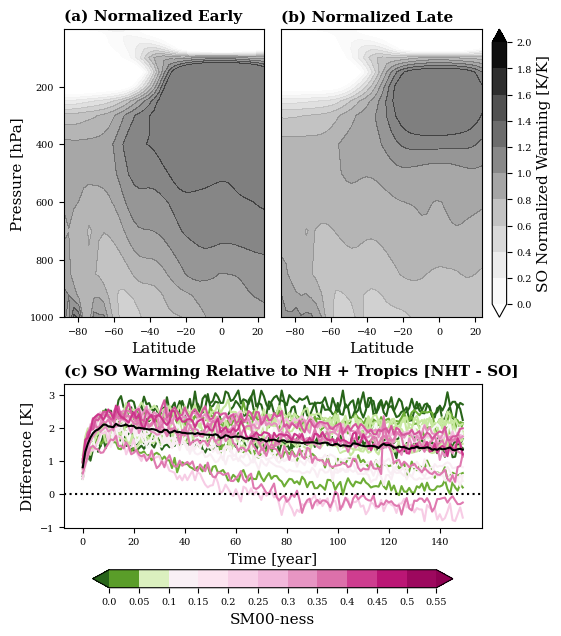

In [25]:
fig, axd = plt.subplot_mosaic(
    [['normearly','normlate'],
    ['timeseries2','timeseries2']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [1,.5],
    figsize = (5.5,6.25))

df = pd.DataFrame(
    dict(data_socnens = [v['lats']['diff_ts'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = modelnames
    )
)
df_sorted = df.sort_values('names')
df_sorted = df_sorted.reset_index(drop=True)
df_merge = pd.merge(feedbacks_merge,df_sorted,how='inner',on='names')

majorlabel = 11
minorlabel = 7

data = np.nanmean([v['TempProf']['norm_earlysocn'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat'].sel(lat=slice(-90,25))
lev = temp_mean['plev']
#ax_earlymap = fig.add_subplot(gs[1, 0:2])
axd['normearly'].contourf(lat,lev/100,data[:,0:41],levels=np.linspace(0,2,11),alpha=.5,cmap='Greys',vmin = 0,vmax = 2,extend='both')
axd['normearly'].invert_yaxis()
axd['normearly'].set_xlabel('Latitude',fontsize=majorlabel)
axd['normearly'].tick_params(bottom=True,left=True,top=False,right=False)
axd['normearly'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
#axd['normearly'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
#                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['normearly'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['normearly'].set_title('(a) Normalized Early',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['normearly'].tick_params(axis="both", labelsize=minorlabel)

data = np.nanmean([v['TempProf']['norm_latesocn'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat'].sel(lat=slice(-90,25))
lev = temp_mean['plev']
#ax_latemap = fig.add_subplot(gs[1, 2:4])
axd['normlate'].contourf(lat,lev/100,data[:,0:41],levels=np.linspace(0,2,11),alpha=.5,cmap='Greys',vmin = 0,vmax = 2,extend='both')
axd['normlate'].invert_yaxis()
axd['normlate'].set_xlabel('Latitude',fontsize=majorlabel)
axd['normlate'].tick_params(bottom=True,left=True,top=False,right=False)
axd['normlate'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
#axd['normlate'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
#                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['normlate'].set_title('(b) Normalized Late',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['normlate'].tick_params(bottom=True, top=False, left=False, right=False)
axd['normlate'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['normlate'].tick_params(axis="both", labelsize=minorlabel)

cmap = cm.PiYG_r
bounds = np.linspace(0,2,11)
norm = mpl.colors.Normalize(vmin=0,vmax=2)
sm = plt.cm.ScalarMappable(cmap='Greys', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=np.linspace(0,2,11), ax=[axd['normearly'],axd['normlate']],
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label = 'SO Normalized Warming [K/K]',fontsize=majorlabel)
cbar.set_ticks(np.linspace(0,2,11))
cbar.ax.set_yticklabels(np.round(np.linspace(0,2,11),2), rotation=0, size = minorlabel)

bounds = np.linspace(0,.55,12)
norm = mpl.colors.TwoSlopeNorm(vmin= bounds[0],vcenter=.1,vmax= bounds[-1])
sm = plt.cm.ScalarMappable(cmap='PiYG_r', norm=norm)
sm.set_array([])
data_socnens = [v['lats']['diff_ts'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2']
data_socn = np.nanmean(data_socnens,0)
#ax_timeseries = fig.add_subplot(gs[0, 1:3])
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	axd['timeseries2'].plot(
		df_merge['data_socnens'][ix],#-df_merge['data_socnens'][ix][0],
		color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,1)/3)),
	)
axd['timeseries2'].plot(data_socn,c='k')
axd['timeseries2'].set_ylabel('Difference [K]',fontsize=majorlabel)
axd['timeseries2'].set_xlabel('Time [year]',fontsize=majorlabel)
axd['timeseries2'].set_title('(c) SO Warming Relative to NH + Tropics [NHT - SO] ',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['timeseries2'].tick_params(axis="both", labelsize=minorlabel)
axd['timeseries2'].axhline(0,c='k',ls=':')

cbar = plt.colorbar(sm, ticks=np.linspace(bounds[0],bounds[-1],bounds.size), ax=[axd['timeseries2']],
         boundaries=bounds,location='bottom',orientation='horizontal',fraction=0.125, pad=0.025,
                   extend='both')
cbar.set_label(label = 'SM00-ness',fontsize=majorlabel)
cbar.set_ticks(np.linspace(bounds[0],bounds[-1],bounds.size))
cbar.ax.set_xticklabels(np.round(np.linspace(bounds[0],bounds[-1],bounds.size),2), rotation=0, size = minorlabel)
plt.savefig(str(savepath+'PaperFig1v3.png'),dpi=300,bbox_inches='tight')

## Figure 2

In [ ]:
fig, axd = plt.subplot_mosaic(
    [['meanstate','stability']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [1],
    figsize = (5.5,3))
majorlabel = 11
minorlabel = 7
pidata = np.nanmean([v['HumProf']['socn_thetaepiprof'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
data = np.nanmean([v['HumProf']['socn_thetae'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
earlydata = np.mean(data[0:10,:],0)
latedata = np.mean(data[-11:-1,:],0)
equiv_pi, = axd['meanstate'].plot(pidata,lev[1:-1]/100,c='darkorchid',label='piControl')
equiv_early, = axd['meanstate'].plot(earlydata,lev[1:-1]/100,c='orchid',alpha=1,ls='--',label='Early abrupt-4xCO2')
equiv_late, = axd['meanstate'].plot(latedata,lev[1:-1]/100,c='orchid',alpha=1,ls=':',label='Late abrupt-4xCO2')
pidata = np.nanmean([v['HumProf']['socn_thetapiprof'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
data = np.nanmean([v['HumProf']['socn_theta'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
earlydata = np.mean(data[0:10,:],0)
latedata = np.mean(data[-11:-1,:],0)
potent_pi, = axd['meanstate'].plot(pidata,lev[1:-1]/100,c='darkgreen')
potent_early, = axd['meanstate'].plot(earlydata,lev[1:-1]/100,c='green',alpha=1,ls='--')
potent_late, = axd['meanstate'].plot(latedata,lev[1:-1]/100,c='green',alpha=1,ls=':')
axd['meanstate'].invert_yaxis()
axd['meanstate'].set_xlim([250,350])
# Creating custom legend handles
handles = [(equiv_pi, potent_pi), (equiv_early, potent_early), (equiv_late, potent_late)]
labels = ['piControl','Early abrupt-4xCO2','Late abrupt-4xCO2']
axd['meanstate'].legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},fontsize=minorlabel,loc=1,edgecolor='none',facecolor='none')
axd['meanstate'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['meanstate'].set_xlabel('Equivalent Potential Temperature [K]',fontsize=majorlabel)
axd['meanstate'].set_title('(a) Mean States',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['meanstate'].tick_params(axis="both", labelsize=minorlabel)

data = np.nanmean([v['HumProf']['socn_thetaeanom'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
dataearly = np.nanmean(data[0:10,:],0)
datalate = np.nanmean(data[140:150,:],0)
earlyshift = dataearly - dataearly[0]
lateshift = datalate - datalate[0]
thetaediffprof = lateshift-earlyshift
data = np.array([v['HumProf']['socn_thetaeanom'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'])
dataearly = np.nanmean(data[:,0:10,:],1)
datalate = np.nanmean(data[:,140:150,:],1)
earlyshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
lateshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
for i in np.arange(0,dataearly.shape[0],1):
    earlyshift[i,:] = dataearly[i,:] - dataearly[i,0]
    lateshift[i,:] = datalate[i,:] - datalate[i,0]
thetaediffprofens = lateshift-earlyshift
socnpt_diffprof = np.nanmean([v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
axd['stability'].plot( socnpt_diffprof ,lev[1:-1]/100,c='darkgreen',label='Potential')
for i in np.arange(0,len(modellist),1):
    axd['stability'].plot(([v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'][i]),lev[1:-1]/100,c='darkgreen',alpha=.25,lw=.5)
axd['stability'].plot( thetaediffprof ,lev[1:-1]/100,c='orchid',label='Equivalent Potential')
for i in np.arange(0,len(modellist2),1):
    axd['stability'].plot((thetaediffprofens[i]),lev[1:-1]/100,c='orchid',alpha=.375,lw=.5)
axd['stability'].invert_yaxis()
axd['stability'].set_title('(b) Stability Change',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['stability'].axvspan(-15,0, facecolor='k', alpha=0.15, zorder=-100)
axd['stability'].axvspan(0,15, facecolor = 'k', alpha = 0, zorder=-100)
legend = axd['stability'].legend(loc=1,fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['stability'].set_xlim([-5,5])
axd['stability'].set_xlabel('Temperature Shift [K]',fontsize=majorlabel)
axd['stability'].tick_params(bottom=True, top=False, left=False, right=False)
axd['stability'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['stability'].tick_params(axis="x", labelsize=minorlabel)\
axd['stability'].text(x=-4.5,y=925,s='Destabilizing',fontsize=minorlabel)
axd['stability'].text(x=2.6,y=925,s='Stabilizing',fontsize=minorlabel)
plt.savefig(str(savepath+'PaperFig2v2.png'),dpi=300,bbox_inches='tight')

## Figure 3

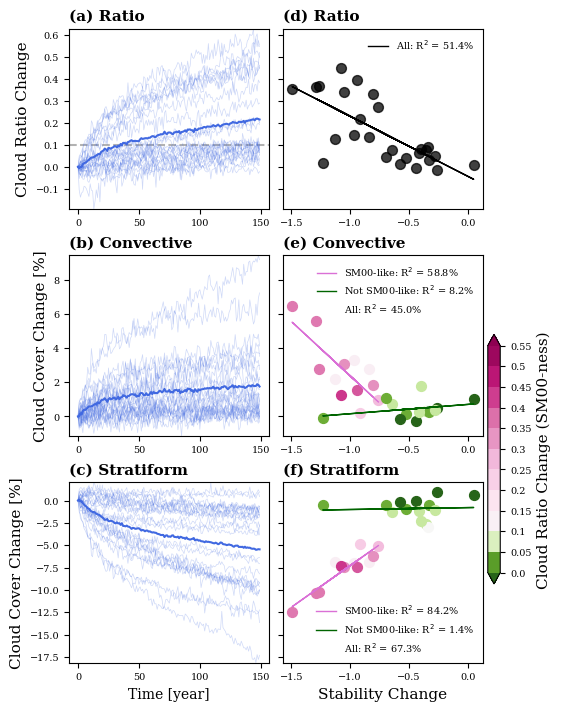

In [34]:
exp_i = 'abrupt-4xCO2'
fig, axd = plt.subplot_mosaic(
    [['ratiots','ratiocorr'],
    ['convts','convcorr'],
    ['stratts','stratcorr']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [1,1,1],
    figsize = (5.5,7))

majorlabel = 11
minorlabel = 7
sm00cutoff = .1

cmap = cm.PiYG_r
bounds = np.linspace(0,.55,12)
norm = mpl.colors.TwoSlopeNorm(vmin= bounds[0],vcenter=.1,vmax= bounds[-1])
sm = plt.cm.ScalarMappable(cmap='PiYG_r', norm=norm)
sm.set_array([])

dataens = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == exp_i]
data = np.nanmean(dataens,0)
axd['ratiots'].axhline(y=.1,color='k',alpha=.3,zorder=-100,ls='--')
axd['ratiots'].plot(data,c='royalblue')
for i in np.arange(0,len(modellist),1):
    axd['ratiots'].plot(dataens[i],c='royalblue',alpha=.25,lw=.5)
axd['ratiots'].set_ylabel('Cloud Ratio Change',fontsize=majorlabel)
#axd['ratiots'].set_xlabel('Time [year]',fontsize=majorlabel)
axd['ratiots'].set_title('(a) Ratio',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['ratiots'].tick_params(axis="both", labelsize=minorlabel)
axd['ratiots'].set_ylim([np.min(dataens),np.max(dataens)])

xvar = pd_merge['cloudstab']
yvar = pd_merge['cloudratio']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
axd['ratiocorr'].scatter(xvar,yvar,c='k',alpha=.75,s=50)
axd['ratiocorr'].plot(xvar,xvar*slope+yint,'k',lw=1,zorder = 2,label = str('All: R$^{2}$ = ' + str(np.round(corr,1))+'%'))
axd['ratiocorr'].set_title('(d) Ratio',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['ratiocorr'].legend(loc=1, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['ratiocorr'].tick_params(axis="both", labelsize=minorlabel)
axd['ratiocorr'].set_ylim([np.min(dataens),np.max(dataens)])
axd['ratiocorr'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)

dataens = [v['ts']['conv_so'] for k, v in cloud_dict.items() if k[0] == exp_i]
data = np.nanmean(dataens,0)
axd['convts'].plot(data-data[0],c='royalblue')
for i in np.arange(0,len(modellist),1):
    axd['convts'].plot(dataens[i]-dataens[i][0],c='royalblue',alpha=.25,lw=.5)
axd['convts'].set_title('(b) Convective',loc='left',fontweight='heavy',fontsize=majorlabel)
#axd['convts'].set_xlabel('Time [year]')
axd['convts'].set_ylabel('Cloud Cover Change [%]',fontsize=majorlabel)
axd['convts'].tick_params(axis="both", labelsize=minorlabel)
axd['convts'].set_ylim([np.min(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1)))),np.max(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1))))])

xvar = pd_merge['cloudstab']
yvar = pd_merge['cloudconv']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
xvarpos = pd_merge[pd_merge['cloudratio'] > sm00cutoff]['cloudstab']
yvarpos = pd_merge[pd_merge['cloudratio'] > sm00cutoff]['cloudconv']
zpos = np.polyfit(xvarpos,yvarpos,1)
slopepos = zpos[0]
yintpos = zpos[1]
corrpos = ((slopepos/(np.std(yvarpos)/np.std(xvarpos)))**2)*100
xvarneg = pd_merge[pd_merge['cloudratio'] < sm00cutoff]['cloudstab']
yvarneg = pd_merge[pd_merge['cloudratio'] < sm00cutoff]['cloudconv']
zneg = np.polyfit(xvarneg,yvarneg,1)
slopeneg = zneg[0]
yintneg = zneg[1]
corrneg = ((slopeneg/(np.std(yvarneg)/np.std(xvarneg)))**2)*100
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	axd['convcorr'].scatter(xvar[ix],yvar[ix],color=cmap(norm(np.round(pd_merge['cloudratio'][ix]*3,1)/3)),s=50)
axd['convcorr'].plot(xvarpos,xvarpos*slopepos+yintpos,'orchid',lw=1,zorder = 2,label = str('SM00-like: R$^{2}$ = ' + str(np.round(corrpos,1))+'%'))
axd['convcorr'].plot(xvarneg,xvarneg*slopeneg+yintneg,'darkgreen',lw=1,zorder = 2,label = str('Not SM00-like: R$^{2}$ = ' + str(np.round(corrneg,1))+'%'))
axd['convcorr'].plot(xvar,xvar*slope+yint,'k',lw=1,zorder = 2,alpha=0,label = str('All: R$^{2}$ = ' + str(np.round(corr,1))+'%'))
#axd['convcorr'].set_xlabel('700 [hPa] Stability Change',fontsize=majorlabel)
axd['convcorr'].set_title('(e) Convective',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['convcorr'].legend(loc=1, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['convcorr'].tick_params(axis="both", labelsize=minorlabel)
axd['convcorr'].set_ylim([np.min(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1)))),np.max(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1))))])
axd['convcorr'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)

cbar = plt.colorbar(sm, ticks=bounds, ax=[axd['convcorr'],axd['stratcorr']],
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label = 'Cloud Ratio Change (SM00-ness)',fontsize=majorlabel)
cbar.set_ticks(bounds)
cbar.ax.set_yticklabels(np.round(bounds,2), rotation=0, size = minorlabel)

dataens = [v['ts']['strat_so'] for k, v in cloud_dict.items() if k[0] == exp_i]
data = np.nanmean(dataens,0)
axd['stratts'].plot(data-data[0],c='royalblue')
for i in np.arange(0,len(modellist),1):
    axd['stratts'].plot(dataens[i]-dataens[i][0],c='royalblue',alpha=.25,lw=.5)
axd['stratts'].set_title('(c) Stratiform',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['stratts'].set_ylabel('Cloud Cover Change [%]',fontsize=majorlabel)
axd['stratts'].set_xlabel('Time [year]')
axd['stratts'].tick_params(axis="both", labelsize=minorlabel)
axd['stratts'].set_ylim([np.min(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1)))),np.max(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1))))])

xvar = pd_merge['cloudstab']
yvar = pd_merge['cloudstrat']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
xvarpos = pd_merge[pd_merge['cloudratio'] > sm00cutoff]['cloudstab']
yvarpos = pd_merge[pd_merge['cloudratio'] > sm00cutoff]['cloudstrat']
zpos = np.polyfit(xvarpos,yvarpos,1)
slopepos = zpos[0]
yintpos = zpos[1]
corrpos = ((slopepos/(np.std(yvarpos)/np.std(xvarpos)))**2)*100
xvarneg = pd_merge[pd_merge['cloudratio'] < sm00cutoff]['cloudstab']
yvarneg = pd_merge[pd_merge['cloudratio'] < sm00cutoff]['cloudstrat']
zneg = np.polyfit(xvarneg,yvarneg,1)
slopeneg = zneg[0]
yintneg = zneg[1]
corrneg = ((slopeneg/(np.std(yvarneg)/np.std(xvarneg))**2)*100)
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	axd['stratcorr'].scatter(xvar[ix],yvar[ix],color=cmap(norm(np.round(pd_merge['cloudratio'][ix]*3,1)/3)),s=50)
axd['stratcorr'].plot(xvarpos,xvarpos*slopepos+yintpos,'orchid',lw=1,zorder = 2,label = str('SM00-like: R$^{2}$ = ' + str(np.round(corrpos,1))+'%'))
axd['stratcorr'].plot(xvarneg,xvarneg*slopeneg+yintneg,'darkgreen',lw=1,zorder = 2,label = str('Not SM00-like: R$^{2}$ = ' + str(np.round(corrneg,1))+'%'))
axd['stratcorr'].plot(xvar,xvar*slope+yint,'k',lw=1,zorder = 2,alpha=0,label = str('All: R$^{2}$ = ' + str(np.round(corr,1))+'%'))
#axd['stratcorr'].set_ylabel('Cloud Cover Change [%]',fontsize=majorlabel)
axd['stratcorr'].set_xlabel('Stability Change',fontsize=majorlabel)
axd['stratcorr'].set_title('(f) Stratiform',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['stratcorr'].tick_params(axis="both", labelsize=minorlabel)
axd['stratcorr'].legend(loc=4, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['stratcorr'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['stratcorr'].set_ylim([np.min(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1)))),np.max(np.subtract(np.array(dataens),np.array(dataens)[:,0].reshape((-1, 1))))])
plt.savefig(str(savepath+'PaperFig3v3.png'),dpi=300,bbox_inches='tight')

## Figure 4

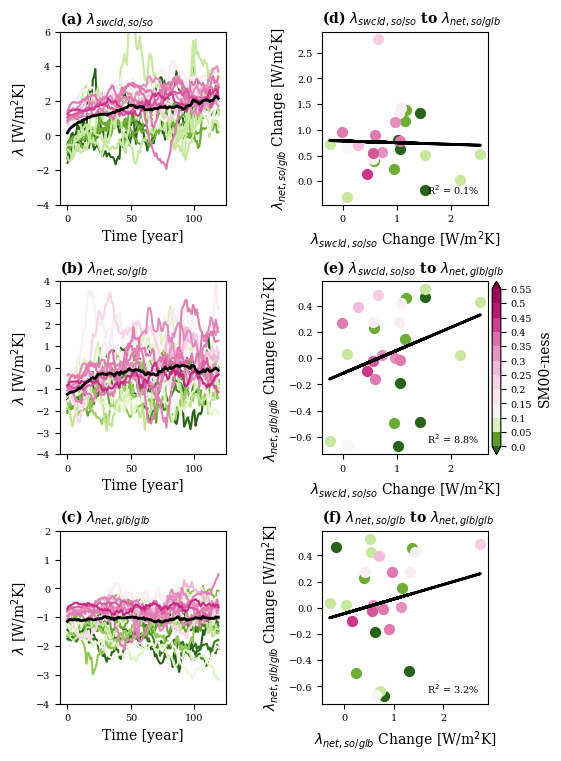

In [35]:
majorlabel = 10
minorlabel = 7

cmap = cm.PiYG_r
bounds = np.linspace(0,.55,12)
norm = mpl.colors.TwoSlopeNorm(vmin= bounds[0],vcenter=.1,vmax= bounds[-1])
sm = plt.cm.ScalarMappable(cmap='PiYG_r', norm=norm)

modelname = [k for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(dataens_swcldsoso = [np.array(v['dRswcldso_dTso']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         dataens_swcldsoglobe = [np.array(v['dRswcldso_dTglobe']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         dataens_netsoglobe = [np.array(v['dRnetso_dTglobe']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         dataens_swcldglobe = [np.array(v['dRswcld_dTglobe']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         dataens_netglobe = [np.array(v['dRnet_dTglobe']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = modelnames
    )
)
df_sorted = df.sort_values('names')
df_sorted = df_sorted.reset_index(drop=True)
df_merge = pd.merge(feedbacks_merge,df_sorted,how='inner',on='names')

fig = plt.figure(figsize=(5.5, 7.5),layout='constrained')
gs = gridspec.GridSpec(nrows=3, ncols=4,  wspace=0.25, height_ratios=[1, 1, 1],figure=fig)

ax_local = fig.add_subplot(gs[0, 0:2])
data = np.mean(np.array(df_merge['dataens_swcldsoso']),0)

for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_local.plot(
		df_merge['dataens_swcldsoso'][ix],
		color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,1)/3)),
	)
ax_local.plot(data,c='k',lw=2)
ax_local.set_xlabel('Time [year]',fontsize=majorlabel)
ax_local.set_ylabel(r'$\lambda$ [W/m$^{2}$K]',fontsize=majorlabel)
ax_local.tick_params(axis="both", labelsize=minorlabel)
ax_local.set_ylim([-4,6])
ax_local.set_title('(a) $\lambda_{swcld,so/so}$',loc='left',fontweight='heavy',fontsize=majorlabel)

ax_locnot = fig.add_subplot(gs[1, 0:2])
data = np.mean(np.array(df_merge['dataens_netsoglobe']),0)
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_locnot.plot(
		df_merge['dataens_netsoglobe'][ix],
		color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,2)/3)),
	)
ax_locnot.plot(data,c='k',lw=2)
ax_locnot.set_xlabel('Time [year]',fontsize=majorlabel)
ax_locnot.set_ylabel(r'$\lambda$ [W/m$^{2}$K]',fontsize=majorlabel)
ax_locnot.tick_params(axis="both", labelsize=minorlabel)
ax_locnot.set_ylim([-4,4])
ax_locnot.set_title('(b) $\lambda_{net,so/glb}$',loc='left',fontweight='heavy',fontsize=majorlabel)

ax_global = fig.add_subplot(gs[2, 0:2])
data = np.mean(np.array(df_merge['dataens_netglobe']),0)
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_global.plot(
		df_merge['dataens_netglobe'][ix],
		color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,2)/3)),
	)
ax_global.plot(data,c='k',lw=2)
ax_global.set_xlabel('Time [year]',fontsize=majorlabel)
ax_global.set_ylabel(r'$\lambda$ [W/m$^{2}$K]',fontsize=majorlabel)
ax_global.tick_params(axis="both", labelsize=minorlabel)
ax_global.set_ylim([-4,2])
ax_global.set_title('(c) $\lambda_{net,glb/glb}$',loc='left',fontweight='heavy',fontsize=majorlabel)

ax_locbal = fig.add_subplot(gs[0, 2:4])
data = np.mean(np.array(df_merge['dataens_swcldsoso']),0)
xvar = feedbacks_merge['dRswcldso_dTso_change']
yvar = feedbacks_merge['dRnetso_dTglobe_change']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_locbal.scatter(xvar[ix],yvar[ix],color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,1)/3)),s=50)
ax_locbal.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=1)
ax_locbal.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=0,label = str('R$^{2}$ = ' + str(np.round(corr,1))+'%'))
ax_locbal.legend(loc=4, fontsize=minorlabel,edgecolor='none',facecolor='none')
ax_locbal.set_xlabel('$\lambda_{swcld,so/so}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_locbal.set_ylabel(r'$\lambda_{net,so/glb}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_locbal.tick_params(axis="both", labelsize=minorlabel)
ax_locbal.set_title('(d) $\lambda_{swcld,so/so}$ to $\lambda_{net,so/glb}$',loc='left',fontweight='heavy',fontsize=majorlabel)

xvar = df_merge['dRswcldso_dTso_change']
yvar = df_merge['dRnet_dTglobe_change']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
ax_corr = fig.add_subplot(gs[1, 2:4])
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_corr.scatter(xvar[ix],yvar[ix],color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,1)/3)),s=50)
ax_corr.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=1)
ax_corr.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=0,label = str('R$^{2}$ = ' + str(np.round(corr,1))+'%'))
ax_corr.legend(loc=4, fontsize=minorlabel,edgecolor='none',facecolor='none')
ax_corr.set_xlabel('$\lambda_{swcld,so/so}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_corr.set_ylabel(r'$\lambda_{net,glb/glb}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_corr.tick_params(axis="both", labelsize=minorlabel)
ax_corr.set_title('(e) $\lambda_{swcld,so/so}$ to $\lambda_{net,glb/glb}$',loc='left',fontweight='heavy',fontsize=majorlabel)


ax_final = fig.add_subplot(gs[2, 2:4])
xvar = df_merge['dRnetso_dTglobe_change']
yvar = df_merge['dRnet_dTglobe_change']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	ax_final.scatter(xvar[ix],yvar[ix],color=cmap(norm(np.round(df_merge['cloudratio'][ix]*3,1)/3)),s=50)
ax_final.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=1)
ax_final.plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=0,label = str('R$^{2}$ = ' + str(np.round(corr,1))+'%'))
ax_final.legend(loc=4, fontsize=minorlabel,edgecolor='none',facecolor='none')
ax_final.set_xlabel('$\lambda_{net,so/glb}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_final.set_ylabel(r'$\lambda_{net,glb/glb}$ Change [W/m$^{2}$K]',fontsize=majorlabel)
ax_final.tick_params(axis="both", labelsize=minorlabel)
ax_final.set_title('(f) $\lambda_{net,so/glb}$ to $\lambda_{net,glb/glb}$',loc='left',fontweight='heavy',fontsize=majorlabel)

cbar = plt.colorbar(sm, ticks=bounds, ax=ax_corr,
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label = 'SM00-ness',fontsize=majorlabel)
cbar.set_ticks(bounds)
cbar.ax.set_yticklabels(np.round(bounds,2), rotation=0, size = minorlabel)
plt.savefig(str(savepath+'PaperFig4.png'),dpi=300,bbox_inches='tight')

# Supplemental Figures

## S. Figure 1

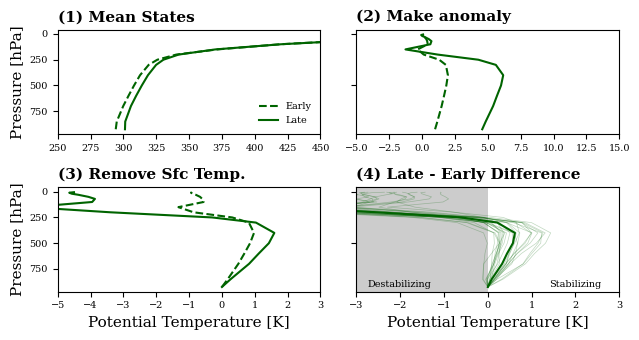

In [21]:
fig, axd = plt.subplot_mosaic(
    [['Tfull','Tanom'],
    ['Tmove','Tdiff']],
    layout = "tight",
    width_ratios = [1,1],
    height_ratios = [1,1],
    figsize = (6.5,3.5))

lat = temp_mean['lat']
lev = temp_mean['plev'].isel(plev=slice(1,-1))

majorlabel = 11
minorlabel = 7

data = np.nanmean([v['HumProf']['socn_thetae'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
socnpt_early = np.mean(data[0:10,:],0)
socnpt_late = np.mean(data[-11:-1,:],0)
socnpt_earlyanom = np.nanmean([v['TempProf']['socntp_earlyanom'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
socnpt_lateanom = np.nanmean([v['TempProf']['socntp_lateanom'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)
socnpt_diffprof = np.nanmean([v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],0)

axd['Tfull'].plot(socnpt_early,lev/100,c='darkgreen',linestyle='--',label='Early')
axd['Tfull'].plot(socnpt_late,lev/100,c='darkgreen',linestyle='-',label='Late')
axd['Tfull'].invert_yaxis()
axd['Tfull'].set_title(r'(1) Mean States',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['Tfull'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['Tfull'].set_xlim([250,450])
axd['Tfull'].tick_params(axis="both", labelsize=minorlabel)
axd['Tfull'].legend(loc=4,fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['Tanom'].plot(socnpt_earlyanom,lev/100,c='darkgreen',linestyle='--',label='Early')
axd['Tanom'].plot(socnpt_lateanom,lev/100,c='darkgreen',linestyle='-',label='Late')
axd['Tanom'].invert_yaxis()
axd['Tanom'].set_xlim([-5,15])
axd['Tanom'].set_title(r'(2) Make anomaly',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['Tanom'].tick_params(bottom=True, top=False, left=True, right=False)
axd['Tanom'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['Tanom'].tick_params(axis="x", labelsize=minorlabel)
axd['Tmove'].plot(socnpt_earlyanom - socnpt_earlyanom[0],lev/100,c='darkgreen',linestyle='--')
axd['Tmove'].plot(socnpt_lateanom - socnpt_lateanom[0],lev/100,c='darkgreen',linestyle='-')
axd['Tmove'].set_xlim([-5,3])
axd['Tmove'].set_title(r'(3) Remove Sfc Temp.',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['Tmove'].invert_yaxis()
axd['Tmove'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['Tmove'].set_xlabel('Potential Temperature [K]',fontsize=majorlabel)
axd['Tmove'].tick_params(axis="both", labelsize=minorlabel)
axd['Tdiff'].plot(socnpt_diffprof,lev/100,c='darkgreen',linestyle='-')
axd['Tdiff'].set_xlim([-3,3])
axd['Tdiff'].set_xlabel('Potential Temperature [K]',fontsize=majorlabel)
axd['Tdiff'].set_title(r'(4) Late - Early Difference',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['Tdiff'].axvspan(-15, 0, facecolor='k', alpha=0.2, zorder=-100,label='Destablizing')
axd['Tdiff'].axvspan(0,15, facecolor = 'k', alpha = 0, zorder=-100,label='Stabilizing')
axd['Tdiff'].invert_yaxis()
for i in np.arange(0,len(modellist),1):
    axd['Tdiff'].plot(([v['TempProf']['socntp_diffprof'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'][i]),lev/100,c='darkgreen',alpha=.25,lw=.5)
axd['Tdiff'].tick_params(bottom=True, top=False, left=True, right=False)
axd['Tdiff'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['Tdiff'].tick_params(axis="x", labelsize=minorlabel)
axd['Tdiff'].text(x=-2.75,y=925,s='Destabilizing',fontsize=minorlabel)
axd['Tdiff'].text(x=1.4,y=925,s='Stabilizing',fontsize=minorlabel)
plt.savefig(str(savepath+'SupplementalFigure1.png'),dpi=300,bbox_inches='tight')

## S. Figure 2

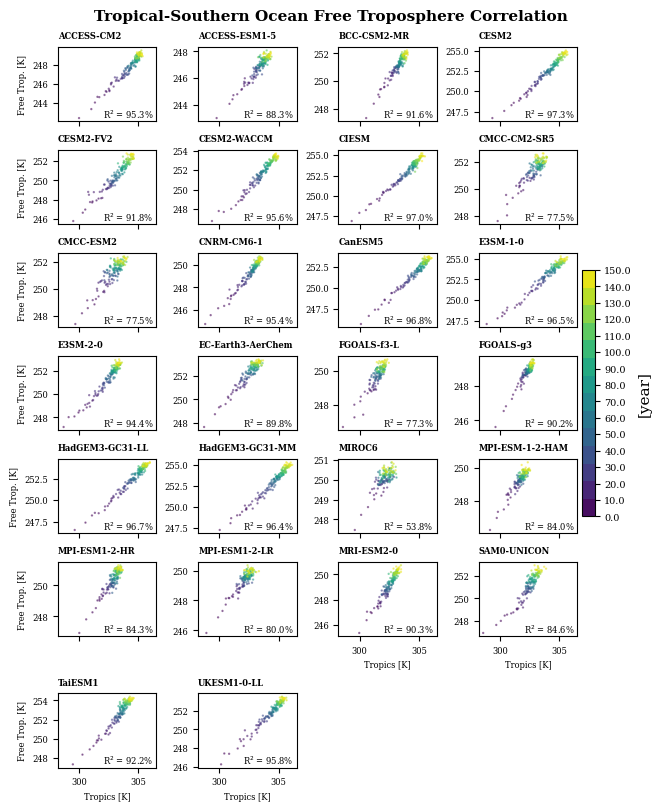

In [36]:
majorlabel = 11
minorlabel = 6
num = len(modellist)
fig,axs = plt.subplots(nrows=7,ncols=4,sharey=False,sharex=True,figsize=(6.5,8),layout='constrained')
exp_i = 'abrupt-4xCO2'
modelname = np.array([k for k, v in temp_dict.items() if k[0] == exp_i])
model_list = modelname[:,1]
df = pd.DataFrame(
    dict(xvar = [v['TempProf']['tropics'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],
         yvar = [v['TempProf']['socn_freetrop'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = model_list
    )
)
df_sorted = df.sort_values('names')
df_sorted = df_sorted.reset_index(drop=True)
df_sorted

bounds = np.linspace(0,150,15)
norm = mpl.colors.Normalize(vmin = 0,vmax = 150)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=np.linspace(0,150,16), ax=axs[1:6,3],
         boundaries=bounds,location='right',label = '[K/K]',orientation='vertical',fraction=0.125, pad=0.05)
cbar.set_label(label='[year]',fontsize=majorlabel)
cbar.set_ticks(np.linspace(0,150,16))
cbar.ax.set_yticklabels(np.round(np.linspace(0,150,16),2), rotation=0, size = 7)
axs = axs.flatten()
for i in np.arange(0,28,1):
    if i < num:
        xvar = df_sorted['xvar'][i]
        yvar = df_sorted['yvar'][i]
        name = df_sorted['names'][i]
        z = np.polyfit(xvar,yvar,1)
        slope = z[0]
        yint = z[1]
        corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
        axs[i].scatter(xvar,yvar,c=np.arange(0,150,1),s=.5,cmap='viridis',alpha=.5,vmin=0,vmax=150)
        axs[i].text(x=302,y=np.min(yvar),s=str('R$^{2}$ = ' + str(np.round(np.array(corr),1))+'%'),fontsize=minorlabel)

        axs[i].set_title(name,fontsize=minorlabel,loc='left',fontweight='heavy')
        axs[i].tick_params(axis="both", labelsize=minorlabel)
    elif i >= num:
        axs[i].axis('off')

axs[0].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[4].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[8].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[12].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[16].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[20].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[24].set_ylabel('Free Trop. [K]',fontsize=minorlabel)
axs[24].set_xlabel('Tropics [K]',fontsize=minorlabel)
axs[25].set_xlabel('Tropics [K]',fontsize=minorlabel)
axs[23].set_xlabel('Tropics [K]',fontsize=minorlabel)
axs[23].tick_params(axis="x", labelbottom=True)
axs[22].set_xlabel('Tropics [K]',fontsize=minorlabel)
axs[22].tick_params(axis='x',labelbottom=True)
plt.suptitle('Tropical-Southern Ocean Free Troposphere Correlation',ha='center',va='top',fontsize=majorlabel,fontweight='heavy')
plt.savefig(str(savepath+'SupplementalFigure2.png'),dpi=300,bbox_inches='tight')

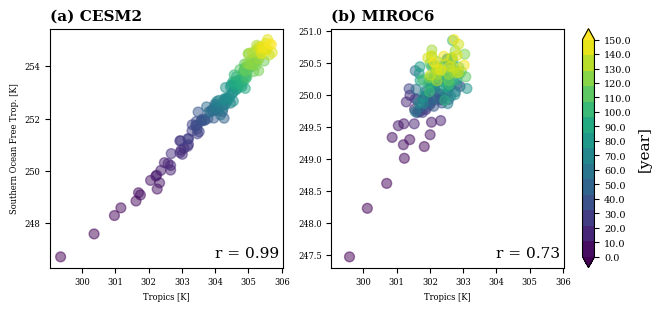

In [34]:
majorlabel = 11
minorlabel = 6
num = len(modellist)
fig,axs = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(6.5,3),layout='constrained')
exp_i = 'abrupt-4xCO2'
modelname = np.array([k for k, v in temp_dict.items() if k[0] == exp_i])
model_list = modelname[:,1]
df = pd.DataFrame(
    dict(xvar = [v['TempProf']['tropics'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],
         yvar = [v['TempProf']['socn_freetrop'] for k, v in temp_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = model_list
    )
)
df_sorted = df.sort_values('names')
df_sorted = df_sorted.reset_index(drop=True)
df_sorted

bounds = np.linspace(0,150,15)
norm = mpl.colors.Normalize(vmin = 0,vmax = 150)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=np.linspace(0,150,16), ax=axs[1],
         boundaries=bounds,location='right',label = '[K/K]',orientation='vertical',fraction=0.125, pad=0.05)
cbar.set_label(label='[year]',fontsize=majorlabel)
cbar.set_ticks(np.linspace(0,150,16))
cbar.ax.set_yticklabels(np.round(np.linspace(0,150,16),2), rotation=0, size = 7)
axs = axs.flatten()
for i in np.arange(0,28,1):
    if i == 3: #CESM2
        xvar = df_sorted['xvar'][i]
        yvar = df_sorted['yvar'][i]
        name = df_sorted['names'][i]
        z = np.polyfit(xvar,yvar,1)
        slope = z[0]
        yint = z[1]
        corr = np.array(slope/(np.std(yvar)/np.std(xvar)))
        axs[0].scatter(xvar,yvar,c=np.arange(0,150,1),s=50,cmap='viridis',alpha=.5,vmin=0,vmax=150)
        axs[0].text(x=304,y=np.min(yvar),s=str('r = ' + str(np.round(corr,2))),fontsize=majorlabel)
        axs[0].set_ylabel('Southern Ocean Free Trop. [K]',fontsize=minorlabel)
        axs[0].set_xlabel('Tropics [K]',fontsize=minorlabel)
        axs[0].set_title(str('(a) '+name),fontsize=majorlabel,loc='left',fontweight='heavy')
        axs[0].tick_params(axis="both", labelsize=minorlabel)
    if i == 18: #MIROC6
        xvar = df_sorted['xvar'][i]
        yvar = df_sorted['yvar'][i]
        name = df_sorted['names'][i]
        z = np.polyfit(xvar,yvar,1)
        slope = z[0]
        yint = z[1]
        corr = np.array(slope/(np.std(yvar)/np.std(xvar)))
        axs[1].scatter(xvar,yvar,c=np.arange(0,150,1),s=50,cmap='viridis',alpha=.5,vmin=0,vmax=150)
        axs[1].text(x=304,y=np.min(yvar),s=str('r = ' + str(np.round(corr,2))),fontsize=majorlabel)
        axs[1].set_xlabel('Tropics [K]',fontsize=minorlabel)
        axs[1].set_title(str('(b) '+name),fontsize=majorlabel,loc='left',fontweight='heavy')
        axs[1].tick_params(axis="both", labelsize=minorlabel)
        plt.savefig(str(savepath+'SupplementalFigure2_presentation.png'),dpi=300,bbox_inches='tight')

## S. Figure 3

In [ ]:
fig, axd = plt.subplot_mosaic(
    [['humidityearly','humiditylate'],
    ['thetaeearly','thetaelate']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [1,1],
    figsize = (6.5,5))
majorlabel = 11
minorlabel = 6
data = np.nanmean([v['HumProf']['hus_earlynorm'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat']
lev = temp_mean['plev']
axd['humidityearly'].contourf(lat,lev/100,data,cmap='RdBu',levels=np.linspace(0,2,11),vmin = 0,vmax = 2)
axd['humidityearly'].invert_yaxis()
axd['humidityearly'].set_xlabel('Latitude',fontsize=majorlabel)
axd['humidityearly'].tick_params(bottom=True,left=True,top=False,right=False)
axd['humidityearly'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
axd['humidityearly'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['humidityearly'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['humidityearly'].set_title('(a) Specific Humidity Early',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['humidityearly'].tick_params(axis="both", labelsize=minorlabel)

data = np.nanmean([v['HumProf']['hus_latenorm'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat']
lev = temp_mean['plev']
axd['humiditylate'].contourf(lat,lev/100,data,cmap='RdBu',levels=np.linspace(0,2,11),vmin = 0,vmax = 2,extend='both')
axd['humiditylate'].invert_yaxis()
axd['humiditylate'].set_xlabel('Latitude',fontsize=majorlabel)
axd['humiditylate'].tick_params(bottom=True,left=True,top=False,right=False)
axd['humiditylate'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
axd['humiditylate'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['humiditylate'].set_title('(b) Specific Humidity Late',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['humiditylate'].tick_params(bottom=True, top=False, left=False, right=False)
axd['humiditylate'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['humiditylate'].tick_params(axis="both", labelsize=minorlabel)

bounds = np.linspace(0,2,11)
norm = mpl.colors.Normalize(vmin = 0,vmax = 2)
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=np.linspace(0,2,11), ax=axd['humiditylate'],
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label='[(gg$^{-1}$)/(gg$^{-1}$)]',fontsize=majorlabel)
cbar.set_ticks(np.linspace(0,2,11))
cbar.ax.set_yticklabels(np.round(np.linspace(0,2,11),2), rotation=0, size = minorlabel)

data = np.nanmean([v['HumProf']['norm_early'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat']
lev = temp_mean['plev']
axd['thetaeearly'].contourf(lat,lev/100,data,cmap='Spectral_r',levels=np.linspace(0,2,11),vmin = 0,vmax = 2,extend='both')
axd['thetaeearly'].invert_yaxis()
axd['thetaeearly'].set_xlabel('Latitude',fontsize=majorlabel)
axd['thetaeearly'].tick_params(bottom=True,left=True,top=False,right=False)
axd['thetaeearly'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
axd['thetaeearly'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['thetaeearly'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['thetaeearly'].set_title('(c) $\Theta_{e}$ Early',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['thetaeearly'].tick_params(axis="both", labelsize=minorlabel)

data = np.nanmean([v['HumProf']['norm_late'] for k, v in humidity_dict.items() if k[0] == 'abrupt-4xCO2'],0)
lat = temp_mean['lat']
lev = temp_mean['plev']
axd['thetaelate'].contourf(lat,lev/100,data,cmap='Spectral_r',levels=np.linspace(0,2,11),vmin = 0,vmax = 2,extend='both')
axd['thetaelate'].invert_yaxis()
axd['thetaelate'].set_xlabel('Latitude',fontsize=majorlabel)
axd['thetaelate'].tick_params(bottom=True,left=True,top=False,right=False)
axd['thetaelate'].tick_params(labelbottom=True,labelleft=True,labeltop=False,labelright=False)
axd['thetaelate'].add_patch(mpatches.Rectangle(xy=[-60, 1000], width=20, height=-1000,
                                        facecolor='none', edgecolor='k', linewidth=.5))
axd['thetaelate'].set_title('(d) $\Theta_{e}$ Late',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['thetaelate'].tick_params(bottom=True, top=False, left=False, right=False)
axd['thetaelate'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['thetaelate'].tick_params(axis="both", labelsize=minorlabel)

bounds = np.linspace(0,2,11)
norm = mpl.colors.Normalize(vmin = 0,vmax = 2)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=np.linspace(0,2,11), ax=axd['thetaelate'],
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label='[K/K]',fontsize=majorlabel)
cbar.set_ticks(np.linspace(0,2,11))
cbar.ax.set_yticklabels(np.round(np.linspace(0,2,11),2), rotation=0, size = minorlabel)
plt.savefig(str(savepath+'SupplementalFigure3.png'),dpi=300,bbox_inches='tight')

## S. Figure 4

In [ ]:
#Comparison of Theta and Theta_e
majorlabel = 11
minorlabel = 7

fig,axs = plt.subplots(nrows=1,ncols=2,layout='constrained',figsize=(6.5,3))
axs = axs.flatten()
equiv_pi, = axs[0].plot(socn_thetaeclim,thetae_early['plev']/100,c='darkorchid',label='piControl')
equiv_early, = axs[0].plot(thetae_early,thetae_early['plev']/100,c='orchid',alpha=1,ls='--',label='Early abrupt-4xCO2')
equiv_late, = axs[0].plot(thetae_late,thetae_early['plev']/100,c='orchid',alpha=1,ls=':',label='Late abrupt-4xCO2')
potent_pi, = axs[0].plot(socn_thetaclim,thetae_early['plev']/100,c='darkgreen')
potent_early, = axs[0].plot(theta_early,thetae_early['plev']/100,c='green',alpha=1,ls='--')
potent_late, = axs[0].plot(theta_late,thetae_early['plev']/100,c='green',alpha=1,ls=':')
ice_pi, = axs[0].plot(socn_thetaeiclim,thetae_early['plev']/100,c='cadetblue')
ice_early, = axs[0].plot(thetaei_early,thetae_early['plev']/100,c='powderblue',alpha=1,ls='--')
ice_late, = axs[0].plot(thetaei_late,thetae_early['plev']/100,c='powderblue',alpha=1,ls=':')
axs[0].invert_yaxis()
axs[0].set_xlim([250,350])
# Creating custom legend handles
handles = [(equiv_pi, potent_pi, ice_pi), (equiv_early, potent_early, ice_early), (equiv_late, potent_late, ice_late)]
labels = ['piControl','Early abrupt-4xCO2','Late abrupt-4xCO2']
axs[0].legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},fontsize=minorlabel,loc=1,edgecolor='none',facecolor='none')
axs[0].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axs[0].set_xlabel('Potential Temperature [K]',fontsize=majorlabel)
axs[0].set_title('(a) CESM2 Mean States',loc='left',fontweight='heavy',fontsize=majorlabel)
axs[0].tick_params(axis="both", labelsize=minorlabel)

axs[1].plot(theta_lateanom - theta_lateanom[0],thetae_early['plev']/100,c='green',ls='-',label='Potential')
axs[1].plot(thetae_lateanom - thetae_lateanom[0],thetae_early['plev']/100,c='orchid',ls='-',label='Equivalent Potential')
axs[1].plot(thetaei_lateanom - thetaei_lateanom[0],thetae_early['plev']/100,c='powderblue',ls='-',label='Ice Equivalent Potential')
axs[1].invert_yaxis()
axs[1].set_title('(b) CESM2 Late',loc='left',fontweight='heavy',fontsize=majorlabel)
axs[1].set_xlabel('[K]',fontsize=majorlabel)
axs[1].set_xlim([-7.5,7.5])
axs[1].axvspan(0, 15, facecolor='k', alpha=0, zorder=-100)
axs[1].axvspan(-15,0, facecolor = 'k', alpha = 0.2, zorder=-100)
axs[1].legend(loc=0)
axs[1].tick_params(axis="both", labelsize=minorlabel)
axs[1].legend(fontsize=minorlabel,loc=1,edgecolor='none',facecolor='none')
axs[1].text(x=-6.5,y=925,s='Destabilizing',fontsize=minorlabel)
axs[1].text(x=3.6,y=925,s='Stabilizing',fontsize=minorlabel)
plt.savefig(str(savepath+'SupplementalFigure4.png'),dpi=300,bbox_inches='tight')

## S. Figure 5

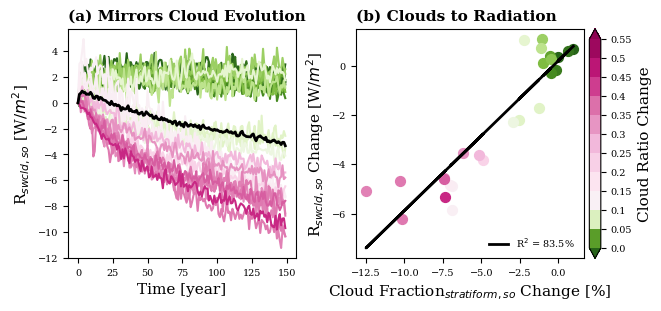

In [31]:
exp_i = 'abrupt-4xCO2'
fig, axd = plt.subplot_mosaic(
    [['swcre_ts','swcrecorr']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [1],
    figsize = (6.5,3))
fig.patch.set_alpha(0)
majorlabel = 11
minorlabel = 7

cmap = cm.PiYG_r
bounds = np.linspace(0,.55,12)
norm = mpl.colors.TwoSlopeNorm(vmin= bounds[0],vcenter=.1,vmax= bounds[-1])
sm = plt.cm.ScalarMappable(cmap='PiYG_r', norm=norm)
sm.set_array([])

modelname = [k for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2']
modelnames = [y for x, y in modelname]
df = pd.DataFrame(
    dict(dataens = [np.array(v['socn_swcreanom']) for k, v in ecs_dict.items() if k[0] == 'abrupt-4xCO2'],
         names = modelnames
    )
)
df_sorted = df.sort_values('names')
df_sorted = df_sorted.reset_index(drop=True)
df_merge = pd.merge(feedbacks_merge,df_sorted,how='inner',on='names')


data = np.mean(np.array(df_merge['dataens']),0)
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	axd['swcre_ts'].plot(
		(-1)*df_merge['dataens'][ix],
		color=cmap(norm(df_merge['cloudratio'][ix])),
	)
axd['swcre_ts'].plot((-1)*data,c='k',lw=2)
axd['swcre_ts'].set_xlabel('Time [year]',fontsize=majorlabel)
axd['swcre_ts'].set_ylabel(r'R$_{swcld,so}$ [W/$m^{2}$]',fontsize=majorlabel)
axd['swcre_ts'].tick_params(axis="both", labelsize=minorlabel)
axd['swcre_ts'].set_title('(a) Mirrors Cloud Evolution',loc='left',fontweight='heavy',fontsize=majorlabel)

cbar = plt.colorbar(sm, ticks=bounds, ax=plt.gca(),
         boundaries=bounds,location='right',orientation='vertical',fraction=0.0625, pad=0.025,
                   extend='both')
cbar.set_label(label = 'Cloud Ratio Change',fontsize=majorlabel)
cbar.set_ticks(bounds)
cbar.ax.set_yticklabels(np.round(bounds,2), rotation=0, size = minorlabel)

xvar = df_merge['strat_change']
yvar = df_merge['swcre_change']*(-1)
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
for ix in np.arange(0,len(df_merge['cloudratio']),1):
	# Plot like normal
	axd['swcrecorr'].scatter(xvar[ix],yvar[ix],color=cmap(norm(df_merge['cloudratio'][ix])),s=50)
axd['swcrecorr'].plot(xvar,xvar*slope+yint,'k',lw=2,zorder = 2,alpha=1,label = str('R$^{2}$ = ' + str(np.round(corr,1))+'%'))
axd['swcrecorr'].legend(loc=4, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['swcrecorr'].set_xlabel('Cloud Fraction$_{stratiform,so}$ Change [%]',fontsize=majorlabel)
axd['swcrecorr'].set_ylabel(r'R$_{swcld,so}$ Change [W/$m^{2}$]',fontsize=majorlabel)
axd['swcrecorr'].tick_params(axis="both", labelsize=minorlabel)
axd['swcrecorr'].set_title('(b) Clouds to Radiation',loc='left',fontweight='heavy',fontsize=majorlabel)

plt.savefig(str(savepath+'SupplementalFigure5.png'),dpi=300,bbox_inches='tight')

## S. Figure 6

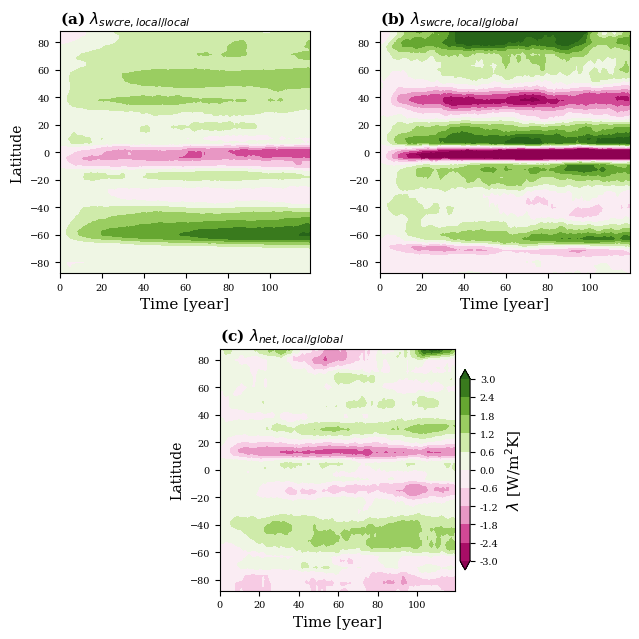

In [25]:
majorlabel = 11
minorlabel = 7
exp_i = 'abrupt-4xCO2'
lat = temp_mean['lat']

fig = plt.figure(figsize=(6.5, 6.5),layout='tight')
gs = gridspec.GridSpec(nrows=2, ncols=4, height_ratios=[1, 1],figure=fig)

ax_temp = fig.add_subplot(gs[0, 0:2])
dataens = [v['swcre_locallocal'] for k, v in hov_dict.items() if k[0] == exp_i]
tas_hovmoller = np.nanmean(dataens,0)
year2 = np.arange(0,120,1)
ax_temp.contourf(year2,lat,tas_hovmoller.T,levels=np.linspace(-3,3,11),vmin = -3,vmax = 3,cmap='PiYG',extend='max')
ax_temp.tick_params(axis="both", labelsize=minorlabel)
ax_temp.set_xlabel('Time [year]',fontsize=majorlabel)
ax_temp.set_ylabel('Latitude')
ax_temp.set_title('(a) $\lambda_{swcre,local/local}$',loc='left',fontweight='heavy',fontsize=majorlabel)

ax_freetrop = fig.add_subplot(gs[0, 2:4])
dataens = [v['swcre_localglobal'] for k, v in hov_dict.items() if k[0] == exp_i]
tas_hovmoller = np.nanmean(dataens,0)
ax_freetrop.contourf(year2,lat,tas_hovmoller.T,levels=np.linspace(-3,3,11),vmin = -3,vmax = 3,cmap='PiYG',extend='both')
ax_freetrop.tick_params(axis="both", labelsize=minorlabel)
ax_freetrop.set_xlabel('Time [year]',fontsize=majorlabel)
ax_freetrop.set_title('(b) $\lambda_{swcre,local/global}$',loc='left',fontweight='heavy',fontsize=majorlabel)

ax_cloud = fig.add_subplot(gs[1, 1:3])
dataens = [v['net_localglobal'] for k, v in hov_dict.items() if k[0] == exp_i]
tas_hovmoller = np.nanmean(dataens,0)
ax_cloud.contourf(year2,lat,tas_hovmoller.T,levels=np.linspace(-3,3,11),vmin = -3,vmax = 3,cmap='PiYG',extend='max')
ax_cloud.tick_params(axis="both", labelsize=minorlabel)
ax_cloud.set_xlabel('Time [year]',fontsize=majorlabel)
ax_cloud.set_ylabel('Latitude')
ax_cloud.set_title('(c) $\lambda_{net,local/global}$',loc='left',fontweight='heavy',fontsize=majorlabel)

bounds = np.linspace(-3,3,11)
norm = mpl.colors.Normalize(vmin = -3,vmax = 3)
sm = plt.cm.ScalarMappable(cmap='PiYG', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=bounds, ax=ax_cloud,
         boundaries=bounds,location='right',orientation='vertical',fraction=0.04, pad=0.02,
                   extend='both')
cbar.set_label(label='$\lambda$ [W/m$^2$K]',fontsize=majorlabel)
cbar.set_ticks(bounds)
cbar.ax.set_yticklabels(np.round(bounds,2), rotation=0, size = 7)

plt.savefig(str(savepath+'SupplementalFigure6.png'),dpi=300,bbox_inches='tight')

## S. Figure 7

In [22]:
merge_merge = pd.merge(feedbacks_merge,hist_merge,how='inner',on='names')

Text(0, 0.5, 'historical SM00ness')

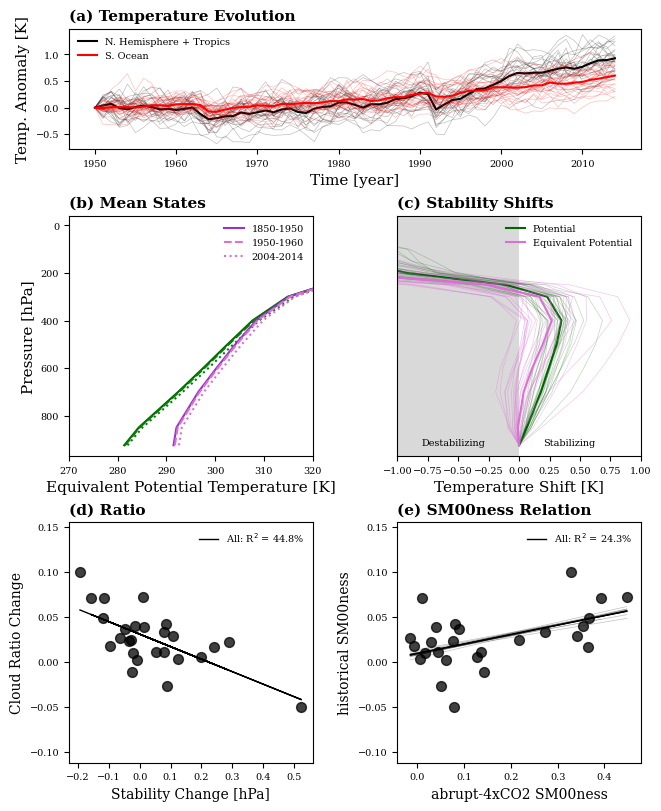

In [28]:
fig, axd = plt.subplot_mosaic(
    [['timeseries','timeseries'],
    ['meanstate','stability'],
    ['ratiocorr','sm00corr']],
    layout = "constrained",
    width_ratios = [1,1],
    height_ratios = [.5,1,.75],
    figsize = (6.5,8))
majorlabel = 11
minorlabel = 7

data_socnens = [v['TempProf']['socn_ts'] for k, v in hist_dict.items() if k[0] == 'historical']
data_nhtens = [v['TempProf']['nht_ts'] for k, v in hist_dict.items() if k[0] == 'historical']
data_nht = np.nanmean(data_nhtens,0)
data_socn = np.nanmean(data_socnens,0)
axd['timeseries'].plot(np.arange(1950,2015,1),data_nht-data_nht[0],c='k',label='N. Hemisphere + Tropics')
for i in np.arange(0,len(modellist),1):
    axd['timeseries'].plot(np.arange(1950,2015,1),data_nhtens[i] - data_nhtens[i][0],c='k',alpha=.25,lw=.5)
axd['timeseries'].plot(np.arange(1950,2015,1),data_socn-data_socn[0],c='r',label='S. Ocean')
for i in np.arange(0,len(modellist),1):
    axd['timeseries'].plot(np.arange(1950,2015,1),data_socnens[i] - data_socnens[i][0],c='r',alpha=.25,lw=.5)
axd['timeseries'].set_ylabel('Temp. Anomaly [K]',fontsize=majorlabel)
axd['timeseries'].set_xlabel('Time [year]',fontsize=majorlabel)
axd['timeseries'].set_title('(a) Temperature Evolution ',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['timeseries'].tick_params(axis="both", labelsize=minorlabel)
axd['timeseries'].legend(fontsize=minorlabel,loc=2,edgecolor='none',facecolor='none')

lev = temp_mean['plev']

pidata = np.nanmean([v['HumProf']['socn_thetaepiprof'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
data = np.nanmean([v['HumProf']['socn_thetae'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
earlydata = np.mean(data[0:10,:],0)
latedata = np.mean(data[-11:-1,:],0)
equiv_pi = axd['meanstate'].plot(pidata,lev[1:-1]/100,c='darkorchid',label='1850-1950')
equiv_early = axd['meanstate'].plot(earlydata,lev[1:-1]/100,c='orchid',alpha=1,ls='--',label='1950-1960')
equiv_late = axd['meanstate'].plot(latedata,lev[1:-1]/100,c='orchid',alpha=1,ls=':',label='2004-2014')
pidata = np.nanmean([v['HumProf']['socn_thetapiprof'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
data = np.nanmean([v['HumProf']['socn_theta'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
earlydata = np.mean(data[0:10,:],0)
latedata = np.mean(data[-11:-1,:],0)
potent_pi = axd['meanstate'].plot(pidata,lev[1:-1]/100,c='darkgreen',zorder=-2)
potent_early = axd['meanstate'].plot(earlydata,lev[1:-1]/100,c='green',alpha=1,ls='--',zorder=-2)
potent_late = axd['meanstate'].plot(latedata,lev[1:-1]/100,c='green',alpha=1,ls=':',zorder=-2)
axd['meanstate'].legend(fontsize=minorlabel,loc=1,edgecolor='none',facecolor='none')
axd['meanstate'].invert_yaxis()
axd['meanstate'].set_xlim([270,320])
axd['meanstate'].set_ylabel('Pressure [hPa]',fontsize=majorlabel)
axd['meanstate'].set_xlabel('Equivalent Potential Temperature [K]',fontsize=majorlabel)
axd['meanstate'].set_title('(b) Mean States',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['meanstate'].tick_params(axis="both", labelsize=minorlabel)

data = np.nanmean([v['HumProf']['socn_thetaeanom'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
dataearly = np.nanmean(data[0:10,:],0)
datalate = np.nanmean(data[55:65,:],0)
earlyshift = dataearly - dataearly[0]
lateshift = datalate - datalate[0]
thetaediffprof = lateshift-earlyshift
data = np.array([v['HumProf']['socn_thetaeanom'] for k, v in hist_dict.items() if k[0] == 'historical'])
dataearly = np.nanmean(data[:,0:10,:],1)
datalate = np.nanmean(data[:,55:65,:],1)
earlyshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
lateshift = np.empty([dataearly.shape[0],dataearly.shape[1]])
for i in np.arange(0,dataearly.shape[0],1):
    earlyshift[i,:] = dataearly[i,:] - dataearly[i,0]
    lateshift[i,:] = datalate[i,:] - datalate[i,0]
thetaediffprofens = lateshift-earlyshift
socnpt_diffprof = np.nanmean([v['TempProf']['socntp_diffprof'] for k, v in hist_dict.items() if k[0] == 'historical'],0)
axd['stability'].plot( socnpt_diffprof ,lev[1:-1]/100,c='darkgreen',label='Potential')
for i in np.arange(0,len(modellist),1):
    axd['stability'].plot(([v['TempProf']['socntp_diffprof'] for k, v in hist_dict.items() if k[0] == 'historical'][i]),lev[1:-1]/100,c='darkgreen',alpha=.25,lw=.5)
axd['stability'].plot( thetaediffprof ,lev[1:-1]/100,c='orchid',label='Equivalent Potential')
for i in np.arange(0,len(modellist),1):
    axd['stability'].plot((thetaediffprofens[i]),lev[1:-1]/100,c='orchid',alpha=.375,lw=.5)
axd['stability'].invert_yaxis()
axd['stability'].set_title('(c) Stability Shifts',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['stability'].axvspan(-15,0, facecolor='k', alpha=0.15, zorder=-100)
axd['stability'].axvspan(0,15, facecolor = 'k', alpha = 0, zorder=-100)
legend = axd['stability'].legend(loc=1,fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['stability'].set_xlim([-1,1])
axd['stability'].set_xlabel('Temperature Shift [K]',fontsize=majorlabel)
axd['stability'].tick_params(bottom=True, top=False, left=False, right=False)
axd['stability'].tick_params(labelbottom=True, labeltop=False, labelleft=False, labelright=False)
axd['stability'].tick_params(axis="x", labelsize=minorlabel)
axd['stability'].text(x=-.8,y=925,s='Destabilizing',fontsize=minorlabel)
axd['stability'].text(x=.2,y=925,s='Stabilizing',fontsize=minorlabel)

dataens = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'historical']
xvar = hist_merge['stabchange']
yvar = hist_merge['histratio']
z = np.polyfit(xvar,yvar,1)
slope = z[0]
yint = z[1]
corr = ((slope/(np.std(yvar)/np.std(xvar)))**2)*100
axd['ratiocorr'].scatter(xvar,yvar,c='k',alpha=.75,s=50)
axd['ratiocorr'].plot(xvar,xvar*slope+yint,'k',lw=1,zorder = 2,label = str('All: R$^{2}$ = ' + str(np.round(corr,1))+'%'))
axd['ratiocorr'].set_title('(d) Ratio',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['ratiocorr'].legend(loc=1, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['ratiocorr'].tick_params(axis="both", labelsize=minorlabel)
axd['ratiocorr'].set_ylim([np.min(dataens),np.max(dataens)])
#axd['ratiocorr'].set_ylim([-.1,.1])
axd['ratiocorr'].tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False)
axd['ratiocorr'].set_xlabel('Stability Change [hPa]')
axd['ratiocorr'].set_ylabel('Cloud Ratio Change')

dataensx = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'abrupt-4xCO2']
dataensy = [v['ts']['socn_c/s_anom'] for k, v in cloud_dict.items() if k[0] == 'historical']
xvar = merge_merge['cloudratio']
yvar = merge_merge['histratio']

slope = np.empty([len(merge_merge['names'])])
yint = np.empty([len(merge_merge['names'])])
for i in np.arange(0,len(merge_merge['names'])):
    jk_xvar = np.delete(xvar,i,0)
    jk_yvar = np.delete(yvar,i,0)
    pfull = np.polyfit(np.squeeze(jk_xvar),np.squeeze(jk_yvar),1)
    
    slope[i] = pfull[0]
    yint[i] = pfull[1]
    
    axd['sm00corr'].plot(jk_xvar,pfull[0]*np.array(jk_xvar)+pfull[1],'k',alpha=.25,lw=.5)
mean_slope = np.mean(slope)
mean_yint = np.mean(yint)
corr = ((mean_slope/(np.std(yvar)/np.std(xvar)))**2)*100
axd['sm00corr'].scatter(xvar,yvar,c='k',alpha=.75,s=50)
axd['sm00corr'].plot(xvar,xvar*mean_slope+mean_yint,'k',lw=1,zorder = 2,label = str('All: R$^{2}$ = ' + str(np.round(corr,1))+'%'))
axd['sm00corr'].set_title('(e) SM00ness Relation',loc='left',fontweight='heavy',fontsize=majorlabel)
axd['sm00corr'].legend(loc=1, fontsize=minorlabel,edgecolor='none',facecolor='none')
axd['sm00corr'].tick_params(axis="both", labelsize=minorlabel)
axd['sm00corr'].set_xlim([np.min(dataensx)+.15,np.max(dataensx)-.15])
axd['sm00corr'].set_ylim([np.min(dataensy),np.max(dataensy)])
axd['sm00corr'].tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False)
axd['sm00corr'].set_xlabel('abrupt-4xCO2 SM00ness')
axd['sm00corr'].set_ylabel('historical SM00ness')

plt.savefig(str(savepath+'SupplementalFigure7.png'),dpi=300,bbox_inches='tight')